In [8]:
import sys
from pathlib import Path
from typing import Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
import seaborn as sns
from scipy.stats import skew, kurtosis, wasserstein_distance
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score
from tqdm.auto import tqdm

# Ensure project root is in path
PROJECT_ROOT = Path(__file__).resolve().parent.parent if "__file__" in globals() else Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_utils import DatasetPT
from src.enc_dec_dataset import MomentsEncoderDecoder, PercentileEncoderDecoder, GMCMEncoderDecoder

In [2]:
DATASET_NAMES = ["BZR", "DHFR", "Mutagenicity", "MUTAG"]
DISCRETE_FEATURES = ["n_nodes", "n_edges"]
CONTINUOUS_FEATURES = [
    "degree_moments_0", "degree_moments_1", "degree_moments_2", "degree_moments_3", 
    "annd_0", "annd_1", "annd_2", "annd_3",
    "eccentricity_0", "eccentricity_1", "eccentricity_2", "eccentricity_3"
]
FEATURES = DISCRETE_FEATURES + CONTINUOUS_FEATURES
IS_DISCRETE = np.array([feat in DISCRETE_FEATURES for feat in FEATURES])
RNG = np.random.default_rng(seed=42)

def load_generation_data() -> pd.DataFrame:
    """Load and preprocess all original datasets and synthetic variants saving all per-graph statistics."""
    rows = []
    original_stats_map = {}

    for dataset_name in DATASET_NAMES:
        # Load original
        orig_pt_path = PROJECT_ROOT / "data" / dataset_name / f"{dataset_name}_original.pt"
        if orig_pt_path.exists():
            dataset_obj = DatasetPT(orig_pt_path)
            per_graph_stats = dataset_obj.metadata.get("per_graph_statistics", [])

            for i, stats in enumerate(per_graph_stats):                
                row = {
                    "dataset": dataset_name,
                    "graph_idx": i,
                    "class_id": dataset_obj[i].y.item(),
                }
                # Flatten the stats dictionary
                for key, value in stats.items():
                    if isinstance(value, (list, np.ndarray)):
                        for idx, val in enumerate(value):
                            row[f"{key}_{idx}"] = val
                    else:
                        row[key] = value
                rows.append(row)
        else:
            print(f"Warning: Original dataset not found at {orig_pt_path}")
                        
    df = pd.DataFrame(rows)
    if "seed" in df.columns:
        df["seed"] = df["seed"].astype("Int64")
    return df

# Load data
df = load_generation_data()
display(df.head(10))

# Initialize Encoder/Decoder with the correct number of classes and discrete info
num_classes = int(df["class_id"].max() + 1)
# ENC_DEC = MomentsEncoderDecoder(num_classes=num_classes, is_discrete=IS_DISCRETE, k=4, rng=RNG)
ENC_DEC = PercentileEncoderDecoder(num_classes=num_classes, is_discrete=IS_DISCRETE, percentile_size=0.1, replicate_correlation=True, rng=RNG)
# ENC_DEC = GMCMEncoderDecoder(num_classes=num_classes, is_discrete=IS_DISCRETE, percentile_size=0.1, n_components=10, rng=RNG)

DATASETS = [d for d in DATASET_NAMES if d in df["dataset"].unique()]

,dataset,graph_idx,class_id,n_nodes,n_edges,modularity,clustering,assortativity,efficiency,diameter,...,degree_moments_2,degree_moments_3,annd_0,annd_1,annd_2,annd_3,eccentricity_0,eccentricity_1,eccentricity_2,eccentricity_3
0,BZR,0,0,30,32,0.584473,0.0,-0.387755,0.305459,10.0,...,-0.086877,1.177793,0.107759,0.107040,0.085386,0.082512,0.301724,0.280172,0.261084,0.246305
1,BZR,1,0,33,35,0.601224,0.0,-0.489362,0.291970,10.0,...,0.060259,1.276020,0.104167,0.100911,0.082031,0.072591,0.284722,0.261719,0.222656,0.242188
2,BZR,2,0,30,32,0.580566,0.0,-0.387755,0.305459,10.0,...,-0.086877,1.177793,0.107759,0.107040,0.085386,0.082512,0.310345,0.271552,0.261084,0.246305
3,BZR,3,0,33,35,0.599184,0.0,-0.489362,0.291970,10.0,...,0.060259,1.276020,0.104167,0.100911,0.082031,0.072591,0.284722,0.261719,0.226562,0.238281
4,BZR,4,0,30,32,0.584473,0.0,-0.387755,0.305459,10.0,...,-0.086877,1.177793,0.107759,0.107040,0.085386,0.082512,0.301724,0.280172,0.261084,0.246305
5,BZR,5,0,33,35,0.598776,0.0,-0.489362,0.291970,10.0,...,0.060259,1.276020,0.104167,0.100911,0.082031,0.072591,0.284722,0.261719,0.222656,0.242188
6,BZR,6,0,30,32,0.584473,0.0,-0.387755,0.305459,10.0,...,-0.086877,1.177793,0.107759,0.107040,0.085386,0.082512,0.310345,0.271552,0.261084,0.246305
7,BZR,7,0,30,32,0.584473,0.0,-0.387755,0.305459,10.0,...,-0.086877,1.177793,0.103448,0.111351,0.085386,0.082512,0.310345,0.271552,0.261084,0.246305
8,BZR,8,0,33,35,0.606939,0.0,-0.489362,0.291970,10.0,...,0.060259,1.276020,0.104167,0.100911,0.082031,0.072591,0.288194,0.257812,0.226562,0.238281
9,BZR,9,0,30,32,0.584473,0.0,-0.387755,0.305459,10.0,...,-0.086877,1.177793,0.107759,0.107040,0.085386,0.082512,0.310345,0.271552,0.261084,0.246305


In [3]:
def encode_and_sample_dataset(df_dataset: pd.DataFrame, dataset_name: str) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Encodes original statistics and samples synthetic ones for all classes in a dataset."""
    embeddings_rows = []
    samples_list = []
    
    for class_id, group in df_dataset.groupby("class_id"):
        # --- Encode ---
        stat_matrix = group[FEATURES].values
        ENC_DEC.encode_features(stat_matrix, class_id)

        # Save encodings for this class
        emb_row = {"class_id": class_id}
        encoding = ENC_DEC._encodings[class_id]
        for i, feat in enumerate(FEATURES):
            emb_row[feat] = encoding[:, i]
        embeddings_rows.append(emb_row)

        # --- Sample ---
        n_samples = len(group)
        samples_matrix = ENC_DEC.sample_features(n_samples, class_id)
    
        # Save samples for this class
        class_samples_df = pd.DataFrame(samples_matrix, columns=FEATURES)
        class_samples_df["class_id"] = class_id
        class_samples_df[DISCRETE_FEATURES] = class_samples_df[DISCRETE_FEATURES].astype(int)
        samples_list.append(class_samples_df)
        
    # Construct final DataFrames
    df_emb = pd.DataFrame(embeddings_rows)
    df_samples = pd.concat(samples_list, ignore_index=True)
    
    df_emb.insert(0, "dataset", dataset_name)
    df_samples.insert(0, "dataset", dataset_name)
    
    return df_emb, df_samples

dataset_embeddings = []
dataset_samples = []

for dataset_name in DATASETS:
    df_subset = df[df["dataset"] == dataset_name]
    df_emb, df_s = encode_and_sample_dataset(df_subset, dataset_name)
    
    dataset_embeddings.append(df_emb)
    dataset_samples.append(df_s)
    
    print(f"\n--- {dataset_name} ---")
    # Get embedding size for the first class (all classes have same embedding size)
    emb_size = ENC_DEC.get_embedding(df_subset["class_id"].iloc[0]).shape[0]
    print(f"Embedding vector dimension: {emb_size}")
    display(df_emb.head())
    display(df_s.head())

df_embeddings = pd.concat(dataset_embeddings, ignore_index=True)
df_synthetic = pd.concat(dataset_samples, ignore_index=True)


--- BZR ---
Embedding vector dimension: 259


,dataset,class_id,n_nodes,n_edges,degree_moments_0,degree_moments_1,degree_moments_2,degree_moments_3,annd_0,annd_1,annd_2,annd_3,eccentricity_0,eccentricity_1,eccentricity_2,eccentricity_3
0,BZR,0,"[20.834130040501545, 29.62609208656454, 31.398...","[22.672994445191595, 31.90383558051846, 34.305...","[0.03634085213032581, 0.047342995169082115, 0....","[0.00043596616855421755, 0.000586369830447552,...","[-0.5816581574292549, -0.3780365340285153, -0....","[1.0017793607503729, 1.1777929679484538, 1.239...","[0.06190476190476191, 0.07377027734170591, 0.0...","[0.061224489795918366, 0.07759652271847393, 0....","[0.04804421768707483, 0.05849189570119802, 0.0...","[0.042091836734693876, 0.05067340067340068, 0....","[0.19909502262443438, 0.24025974025974028, 0.2...","[0.2378472222222222, 0.24915824915824913, 0.26...","[0.1753472222222222, 0.20346320346320346, 0.21...","[0.1909722222222222, 0.2159709338280767, 0.225..."
1,BZR,1,"[13.05401950207071, 22.696014303321622, 24.586...","[12.83544592594926, 23.875697420898845, 26.948...","[0.04408163265306122, 0.050739957716701894, 0....","[0.0004718086214077467, 0.0006673882111134107,...","[-0.6028590428569108, -0.41303411329251727, -0...","[0.7272727272727271, 1.1416590328990475, 1.193...","[0.06382978723404255, 0.07398553827125257, 0.0...","[0.06783746556473828, 0.07716049382716049, 0.0...","[0.053240740740740734, 0.0613107822410148, 0.0...","[0.04701967592592592, 0.05659681227863046, 0.0...","[0.20995670995670995, 0.23783767911674886, 0.2...","[0.20995670995670995, 0.24341503267973857, 0.2...","[0.17099567099567098, 0.20916700013338668, 0.2...","[0.1768707482993197, 0.20313390313390312, 0.22..."


,dataset,n_nodes,n_edges,degree_moments_0,degree_moments_1,degree_moments_2,degree_moments_3,annd_0,annd_1,annd_2,annd_3,eccentricity_0,eccentricity_1,eccentricity_2,eccentricity_3,class_id
0,BZR,33,36,0.066280,0.000919,-0.254240,1.108242,0.094489,0.091001,0.076300,0.072744,0.312918,0.289311,0.257258,0.298074,0
1,BZR,30,32,0.074978,0.000989,-0.572838,1.008570,0.093577,0.102396,0.078132,0.095554,0.328277,0.311832,0.305775,0.273131,0
2,BZR,30,33,0.074343,0.001212,-0.022707,1.299639,0.115746,0.114194,0.086617,0.082792,0.253522,0.250542,0.224865,0.215752,0
3,BZR,34,35,0.064177,0.000997,-0.040157,1.281414,0.094715,0.098041,0.074227,0.070328,0.304397,0.334012,0.245547,0.298721,0
4,BZR,56,59,0.037851,0.000459,0.392282,1.514501,0.065338,0.063403,0.054844,0.042401,0.202972,0.242518,0.177401,0.201928,0



--- DHFR ---
Embedding vector dimension: 259


,dataset,class_id,n_nodes,n_edges,degree_moments_0,degree_moments_1,degree_moments_2,degree_moments_3,annd_0,annd_1,annd_2,annd_3,eccentricity_0,eccentricity_1,eccentricity_2,eccentricity_3
0,DHFR,0,"[19.514975605936595, 36.0823652540752, 37.9227...","[20.66232662133763, 37.67381963761962, 39.8941...","[0.031207598371777476, 0.038383838383838395, 0...","[0.00027059187898348743, 0.0004078427453391558...","[-0.41303411329251816, -0.06532755748039175, 0...","[0.9648786670330307, 1.2999617961309402, 1.359...","[0.05248868778280543, 0.06364532019704433, 0.0...","[0.0493212669683258, 0.06256738544474394, 0.06...","[0.03974358974358975, 0.048137397194000967, 0....","[0.031486742424242424, 0.04140982953413586, 0....","[0.225, 0.25, 0.2603441295546559, 0.2708333333...","[0.21587301587301586, 0.26245039682539684, 0.2...","[0.1926829268292683, 0.22922714078374454, 0.23...","[0.20243902439024392, 0.22745833333333332, 0.2..."
1,DHFR,1,"[19.501571050818253, 29.76693951256556, 33.084...","[20.50813949372394, 31.19290040511594, 35.3574...","[0.029376257545271626, 0.0396103896103896, 0.0...","[0.00025804727762955993, 0.0004709158289142317...","[-0.4260686100651611, -0.15406294099485812, -0...","[0.9648786670330307, 1.246549629527584, 1.2995...","[0.05141129032258065, 0.06873315363881402, 0.0...","[0.05004389815627744, 0.06593406593406594, 0.0...","[0.03981481481481482, 0.051082251082251076, 0....","[0.029271708683473393, 0.04148524431543299, 0....","[0.1948051948051948, 0.25, 0.26406926406926406...","[0.2, 0.2533333333333333, 0.26773049645390073,...","[0.17042606516290726, 0.21893491124260356, 0.2...","[0.1829573934837093, 0.22597402597402597, 0.23..."


...

,dataset,class_id,n_nodes,n_edges,degree_moments_0,degree_moments_1,degree_moments_2,degree_moments_3,annd_0,annd_1,annd_2,annd_3,eccentricity_0,eccentricity_1,eccentricity_2,eccentricity_3
0,Mutagenicity,0,"[4.008494867147286, 15.157123866188122, 18.542...","[2.593325312921631, 15.259617437681223, 18.724...","[0.00154851774095085, 0.051219512195121955, 0....","[7.73189833078082e-06, 0.0007409779891738936, ...","[-0.6442352540027577, -0.3639529426398315, -0....","[0.6363636363636367, 0.9072733392993487, 1.051...","[0.007759562841530054, 0.08153890160183067, 0....","[0.006994535519125683, 0.07946127946127945, 0....","[0.006484517304189436, 0.06581196581196581, 0....","[0.006083788706739528, 0.056839703856749316, 0...","[0.07683060109289618, 0.2504756871035941, 0.27...","[0.07234972677595629, 0.23731924360400447, 0.2...","[0.0774863387978142, 0.2125595238095238, 0.230...","[0.0760655737704918, 0.2126984126984127, 0.235..."
1,Mutagenicity,1,"[5.232912710949412, 13.180987653065575, 16.145...","[3.9752421551737847, 12.619161869646085, 16.10...","[0.0011529238147943183, 0.03734968734968735, 0...","[5.072819591162029e-06, 0.0005047244787478602,...","[-0.47590578526816923, -1.3901040008935916e-15...","[0.5555555555555549, 0.9482132774058247, 1.225...","[0.006634615384615384, 0.06552498048399688, 0....","[0.006009615384615385, 0.06557909303810944, 0....","[0.005913461538461539, 0.054157179720704315, 0...","[0.004740918803418804, 0.04344949921872999, 0....","[0.06586538461538462, 0.2179464285714286, 0.25...","[0.06509615384615385, 0.2300311147186147, 0.26...","[0.06134615384615384, 0.19381461675579323, 0.2...","[0.06009615384615385, 0.19991018910397249, 0.2..."


,dataset,n_nodes,n_edges,degree_moments_0,degree_moments_1,degree_moments_2,degree_moments_3,annd_0,annd_1,annd_2,annd_3,eccentricity_0,eccentricity_1,eccentricity_2,eccentricity_3,class_id
0,Mutagenicity,21,23,0.102832,0.001966,-0.462301,0.922775,0.151194,0.131542,0.117027,0.101045,0.388299,0.365318,0.290571,0.334971,0
1,Mutagenicity,30,31,0.076203,0.001289,0.294842,1.555493,0.120531,0.108253,0.090462,0.077169,0.310390,0.385557,0.262683,0.286177,0
2,Mutagenicity,35,40,0.066262,0.001060,-0.071949,1.501784,0.111641,0.093671,0.077609,0.073188,0.280999,0.290262,0.224183,0.259876,0
3,Mutagenicity,19,19,0.107263,0.001960,-0.245435,1.093609,0.139371,0.117690,0.127731,0.142411,0.366332,0.345255,0.468716,0.307433,0
4,Mutagenicity,29,30,0.075001,0.001597,0.509374,5.293621,0.127914,0.116642,0.088353,0.091041,0.349216,0.307280,0.326400,0.295924,0



--- MUTAG ---
Embedding vector dimension: 259


,dataset,class_id,n_nodes,n_edges,degree_moments_0,degree_moments_1,degree_moments_2,degree_moments_3,annd_0,annd_1,annd_2,annd_3,eccentricity_0,eccentricity_1,eccentricity_2,eccentricity_3
0,MUTAG,0,"[9.745049591651814, 10.750776991062652, 11.136...","[9.563350743385104, 10.916878579043454, 11.344...","[0.09057971014492754, 0.1200378396972824, 0.14...","[0.0012181181012349844, 0.0018514927670052325,...","[-0.4120344771497982, -0.30657262901228804, -0...","[0.8825757575757587, 1.125, 1.2272727272727286...","[0.13043478260869565, 0.15964912280701754, 0.1...","[0.11594202898550723, 0.15, 0.1583333333333333...","[0.09903381642512077, 0.13427083333333337, 0.1...","[0.09206349206349206, 0.11925925925925927, 0.1...","[0.391304347826087, 0.43846153846153846, 0.458...","[0.3115942028985507, 0.37007407407407406, 0.38...","[0.2826086956521739, 0.33403508771929824, 0.35...","[0.2971014492753623, 0.3333333333333333, 0.35,..."
1,MUTAG,1,"[11.548653173544713, 15.069887351255359, 16.62...","[12.1318488086449, 17.085979673903516, 18.8110...","[0.08201058201058202, 0.09333333333333332, 0.1...","[0.0005844108408210973, 0.0008280085612960675,...","[-0.7259810173138147, -0.5530660158545608, -0....","[1.058181818181818, 1.4739220226547336, 1.7918...","[0.10164835164835165, 0.1146103896103896, 0.12...","[0.09259259259259259, 0.1076388888888889, 0.11...","[0.09706959706959704, 0.10862977602108036, 0.1...","[0.07936507936507935, 0.09644444444444444, 0.1...","[0.3131868131868132, 0.3485194805194805, 0.368...","[0.28, 0.30292640692640693, 0.3263157894736842...","[0.2222222222222222, 0.26395534290271133, 0.28...","[0.2371794871794872, 0.2679365079365079, 0.285..."


,dataset,n_nodes,n_edges,degree_moments_0,degree_moments_1,degree_moments_2,degree_moments_3,annd_0,annd_1,annd_2,annd_3,eccentricity_0,eccentricity_1,eccentricity_2,eccentricity_3,class_id
0,MUTAG,14,15,0.167497,0.002116,-0.247351,2.602529,0.191167,0.160207,0.176043,0.179424,0.519962,0.432972,0.426022,0.470091,0
1,MUTAG,19,22,0.125528,0.001452,-0.336305,2.575745,0.159043,0.126759,0.152537,0.124774,0.523938,0.478016,0.365211,0.441314,0
2,MUTAG,15,17,0.145366,0.002150,-0.204204,2.390967,0.185662,0.165512,0.176950,0.123059,0.570266,0.424707,0.439019,0.462271,0
3,MUTAG,13,14,0.179487,0.003528,-0.278246,1.975252,0.225222,0.166780,0.189043,0.195926,0.500000,0.415931,0.406298,0.386892,0
4,MUTAG,11,11,0.200000,0.004055,-0.001098,2.283785,0.266898,0.271899,0.231413,0.198656,0.542292,0.446514,0.424525,0.462347,0


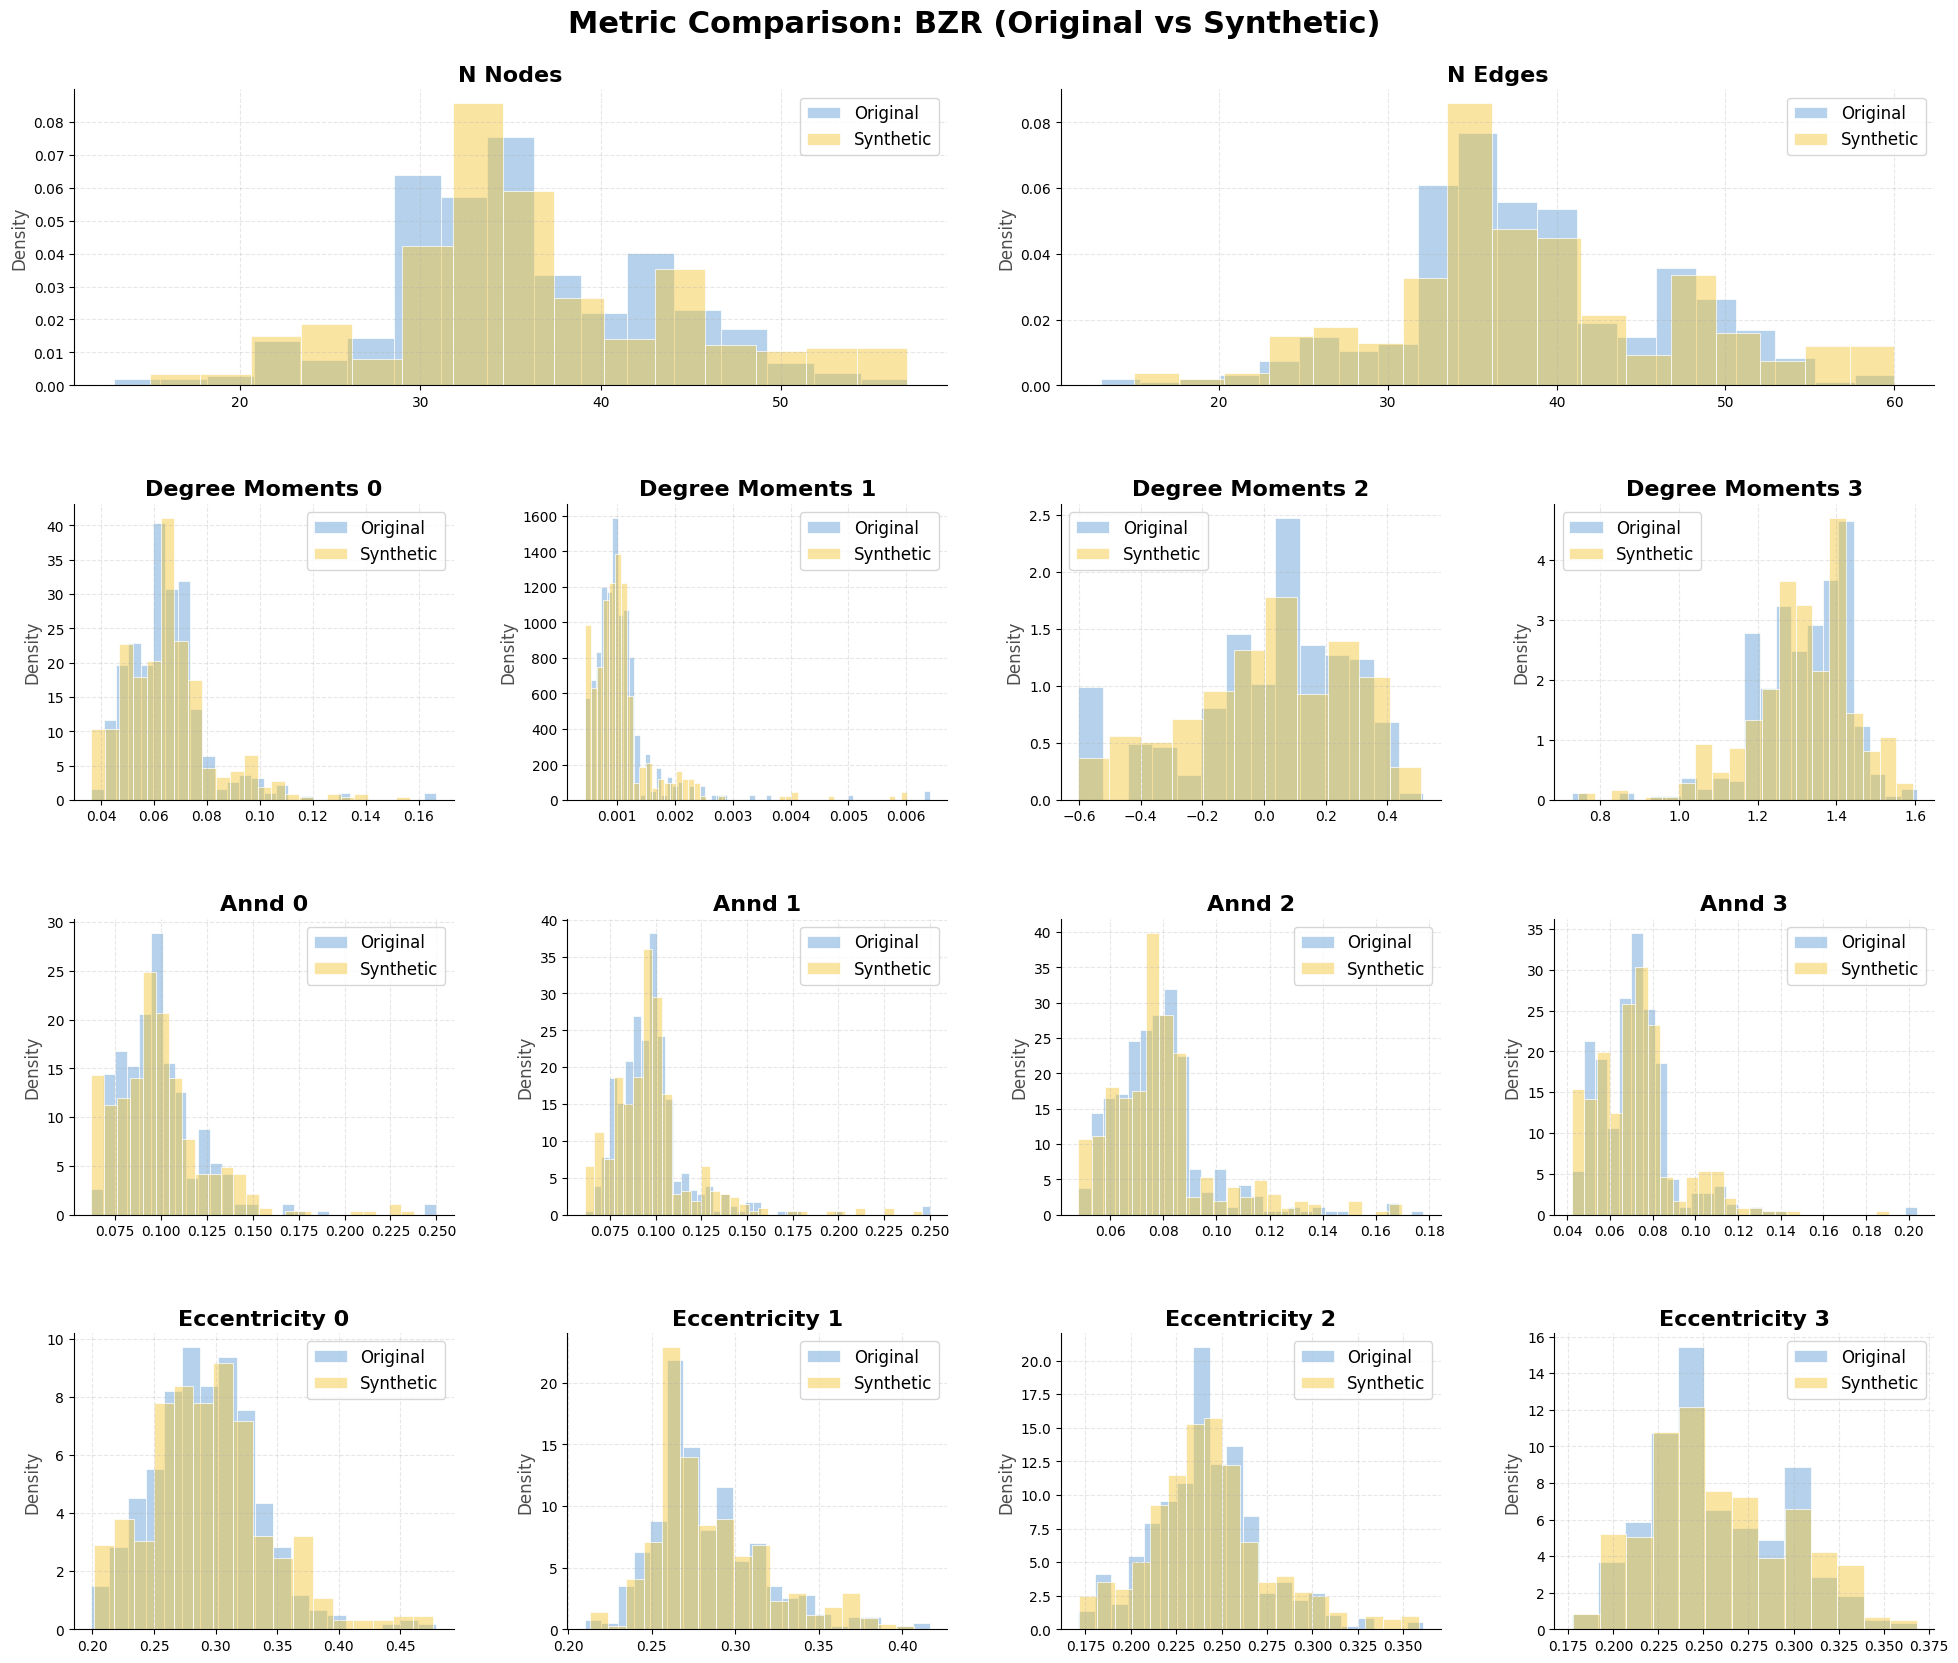

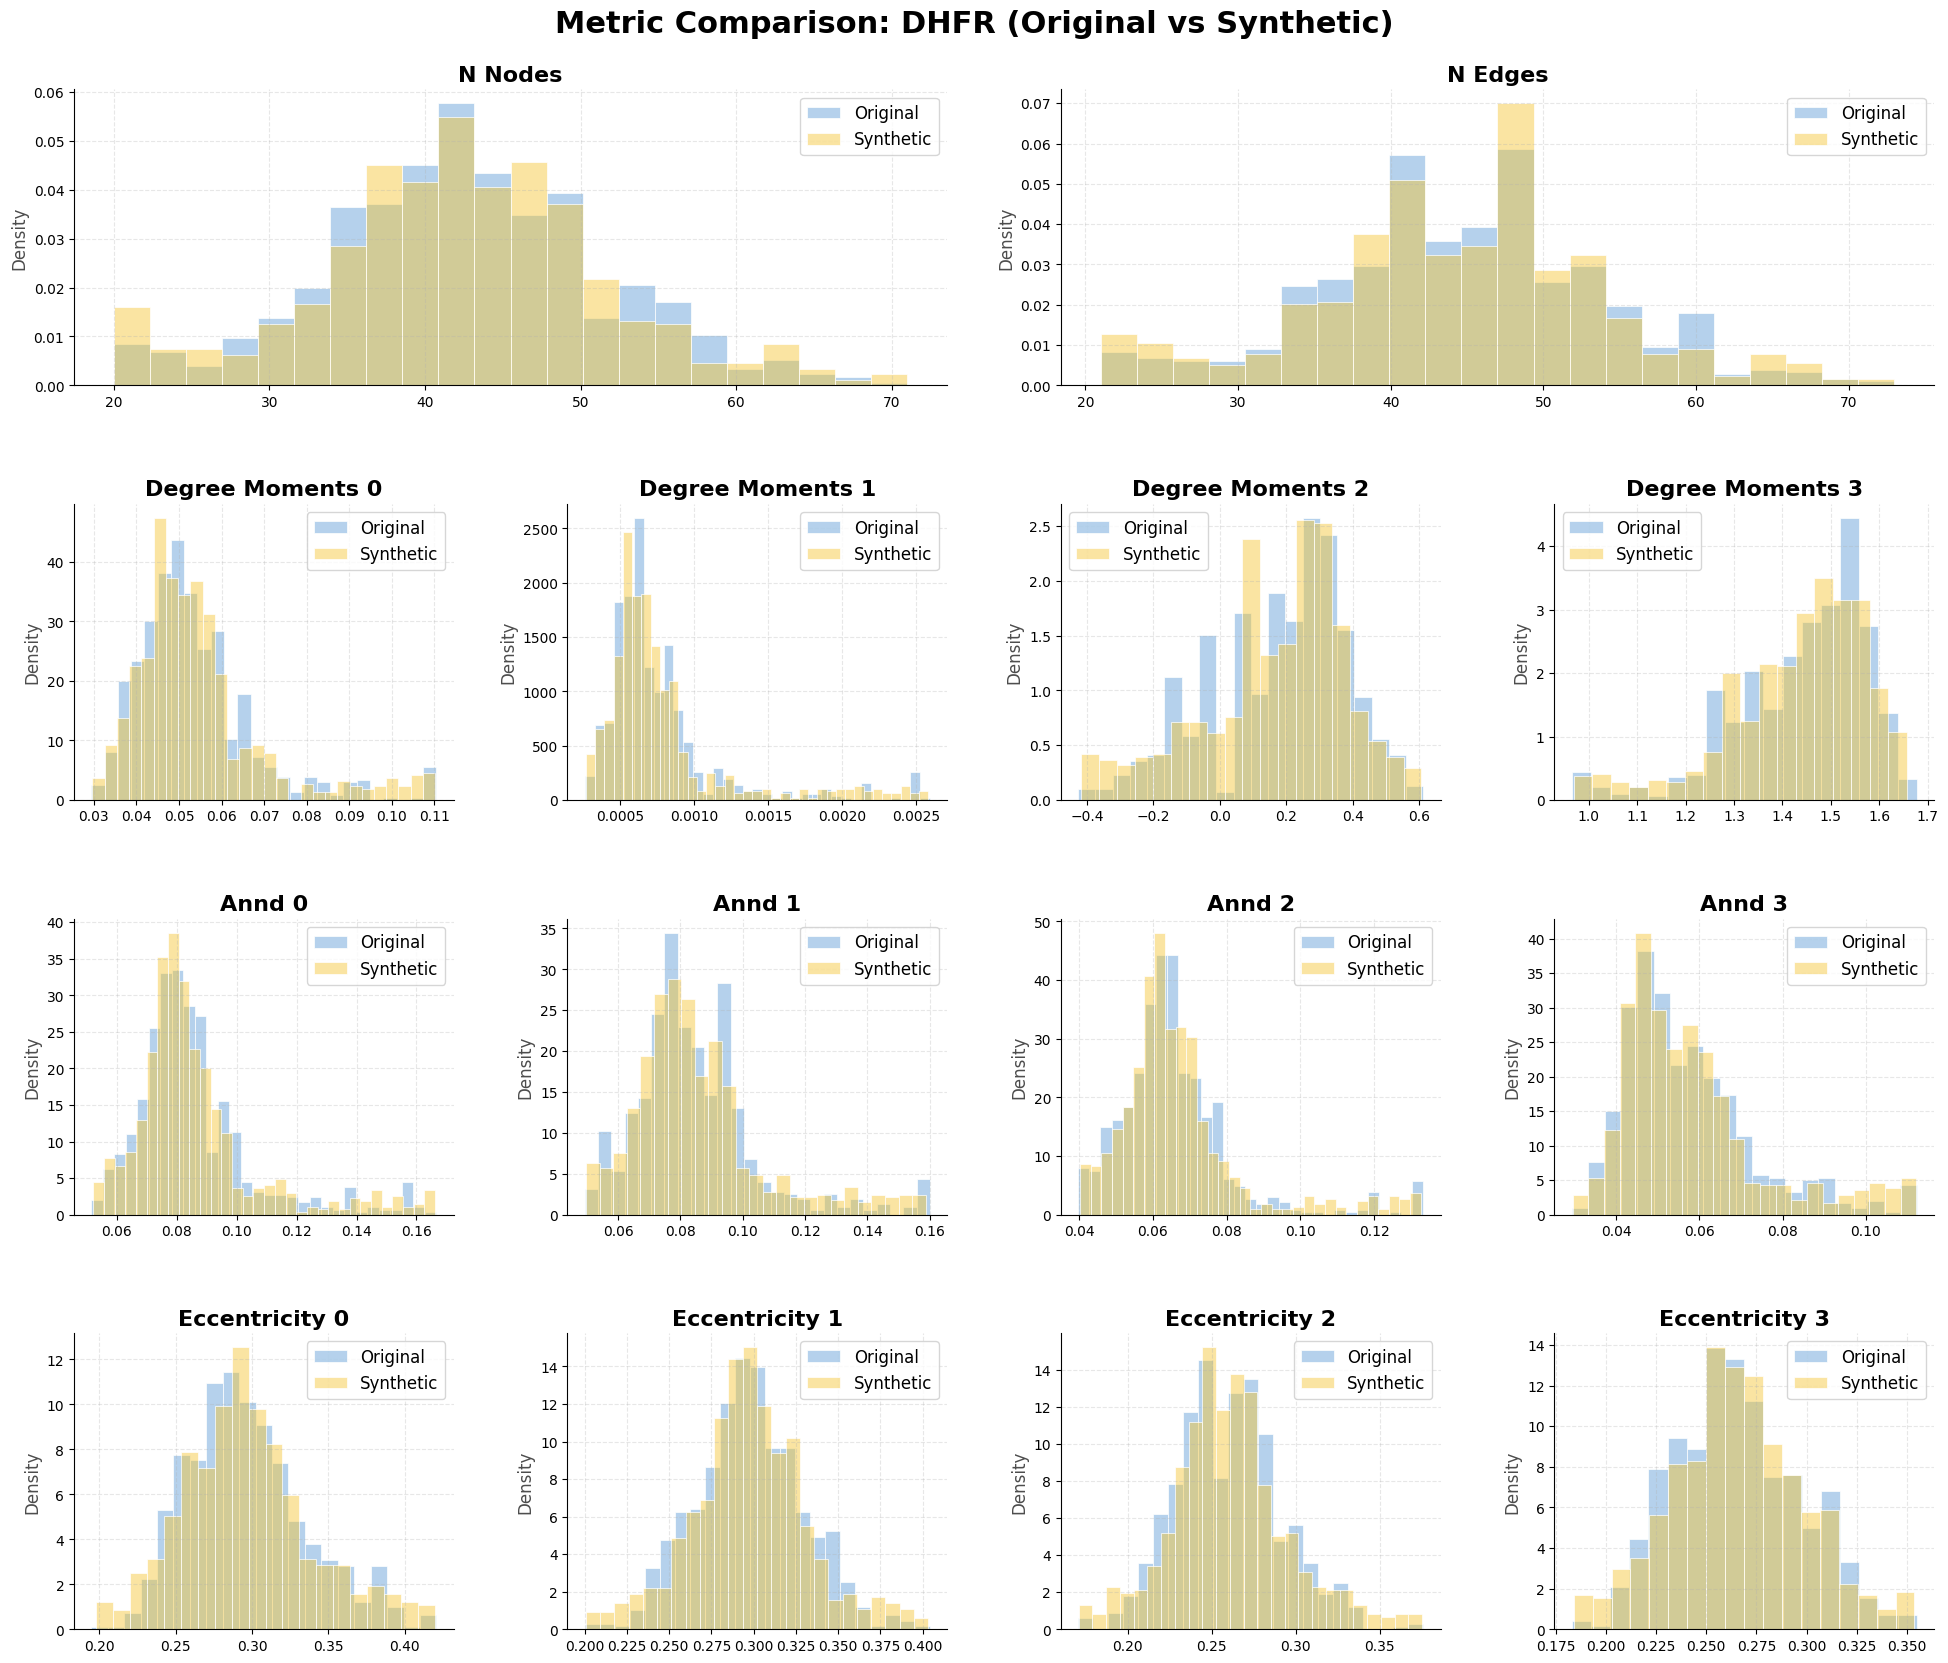

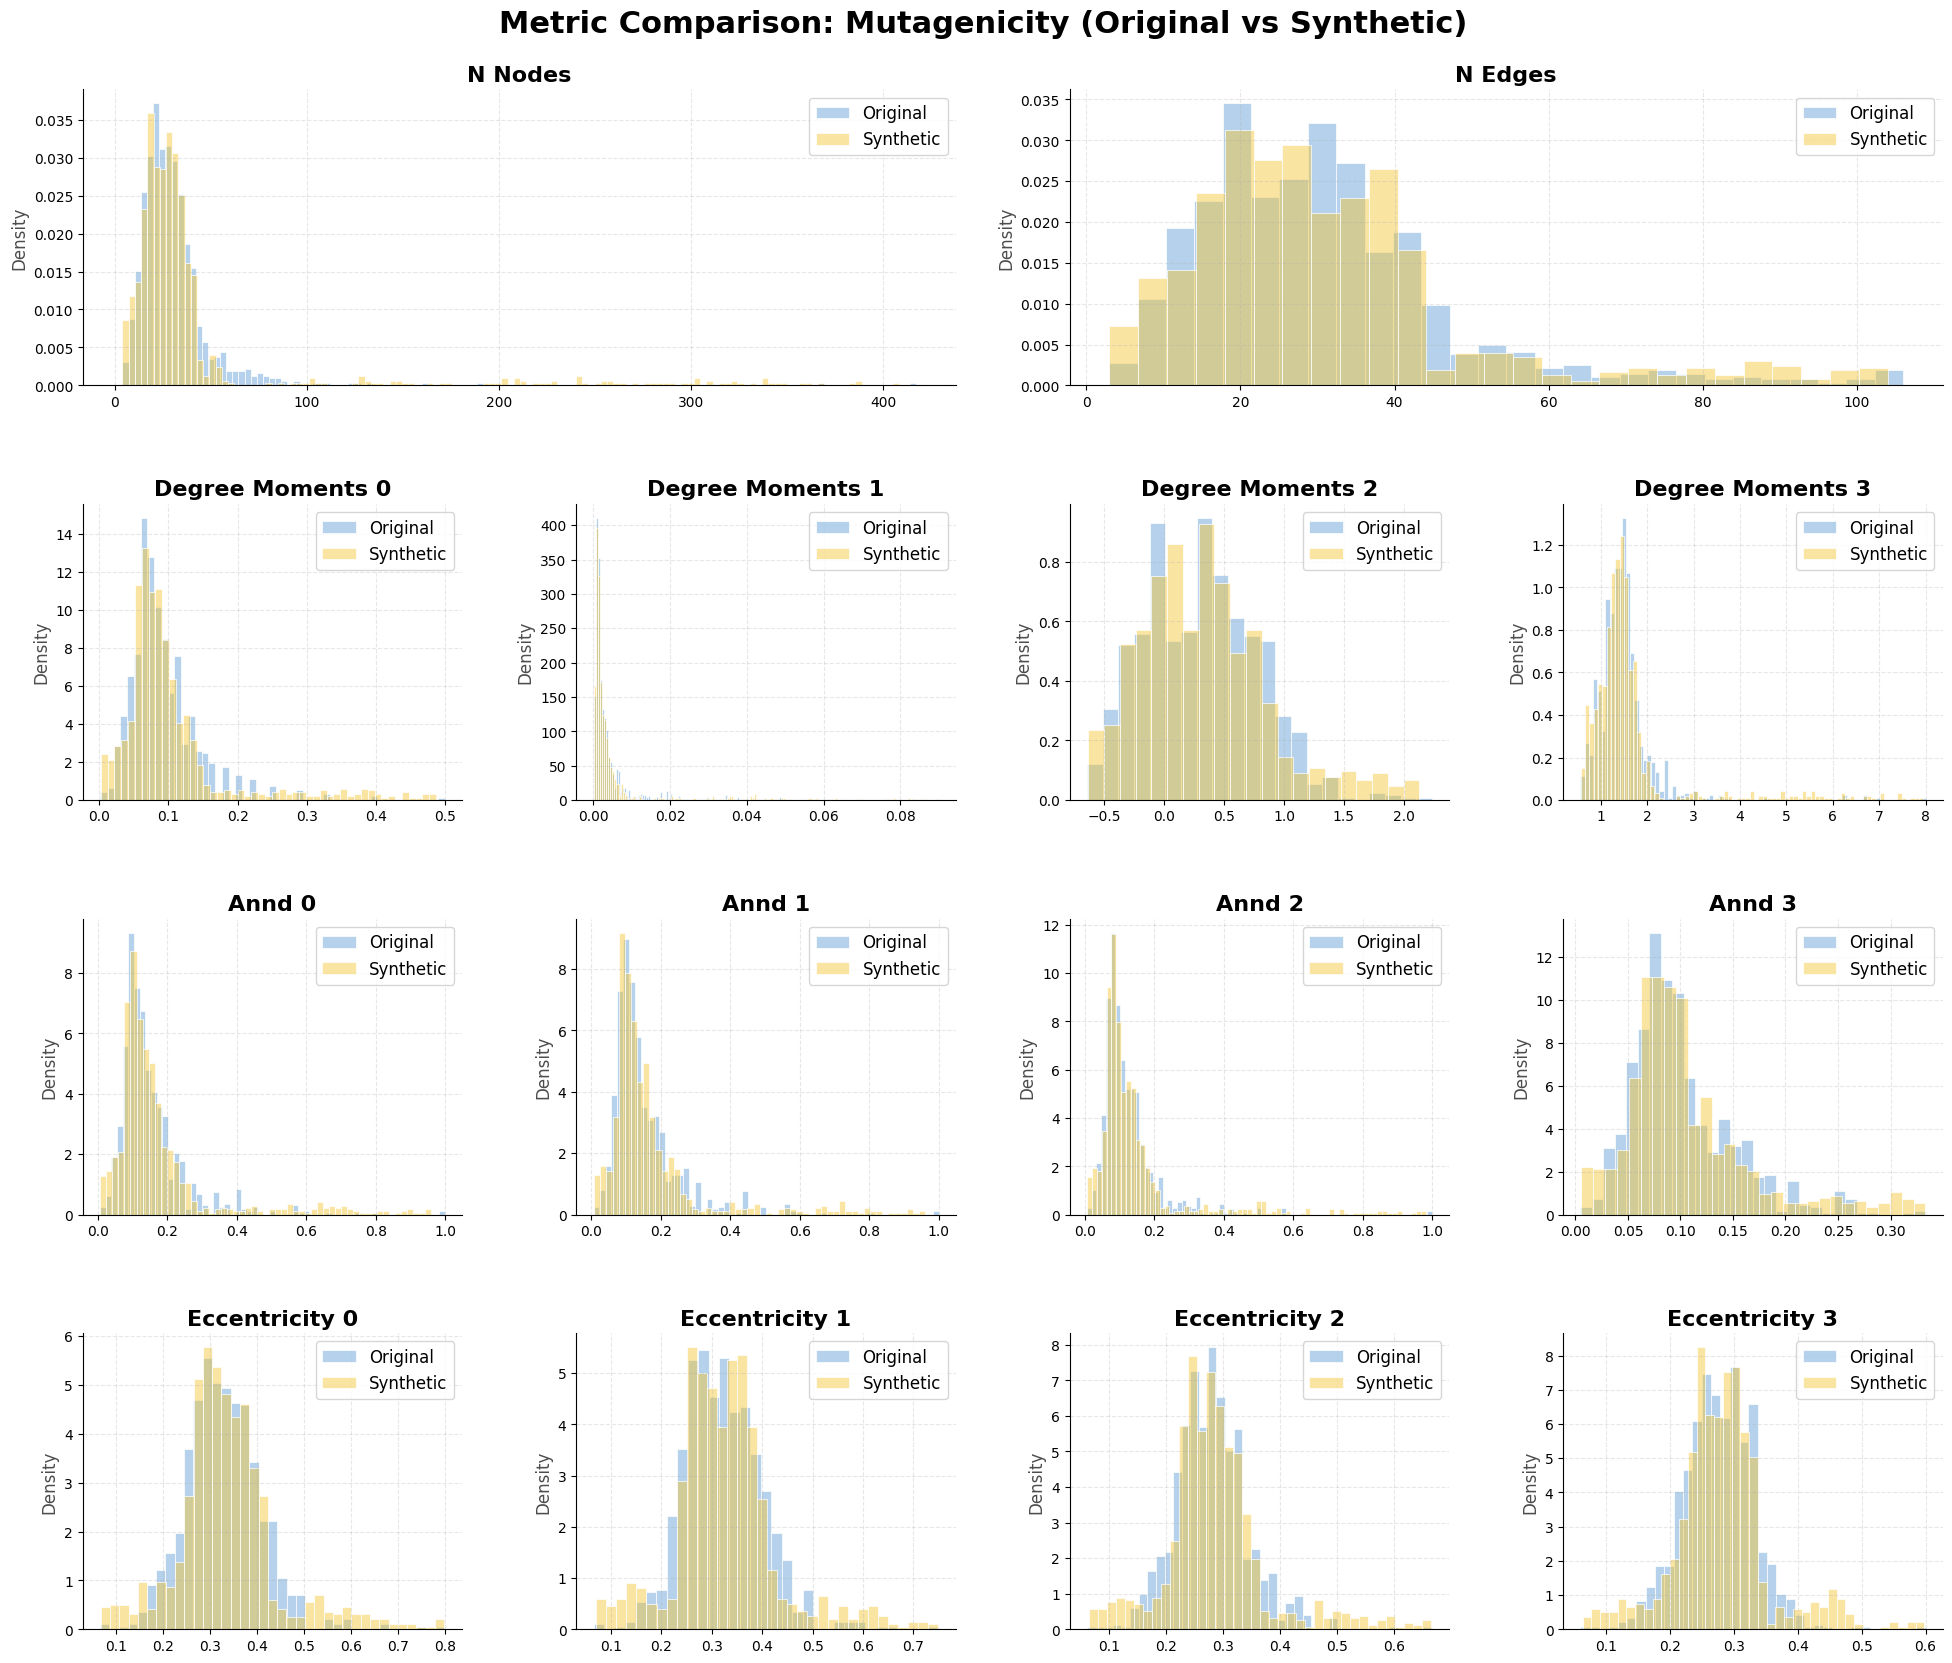

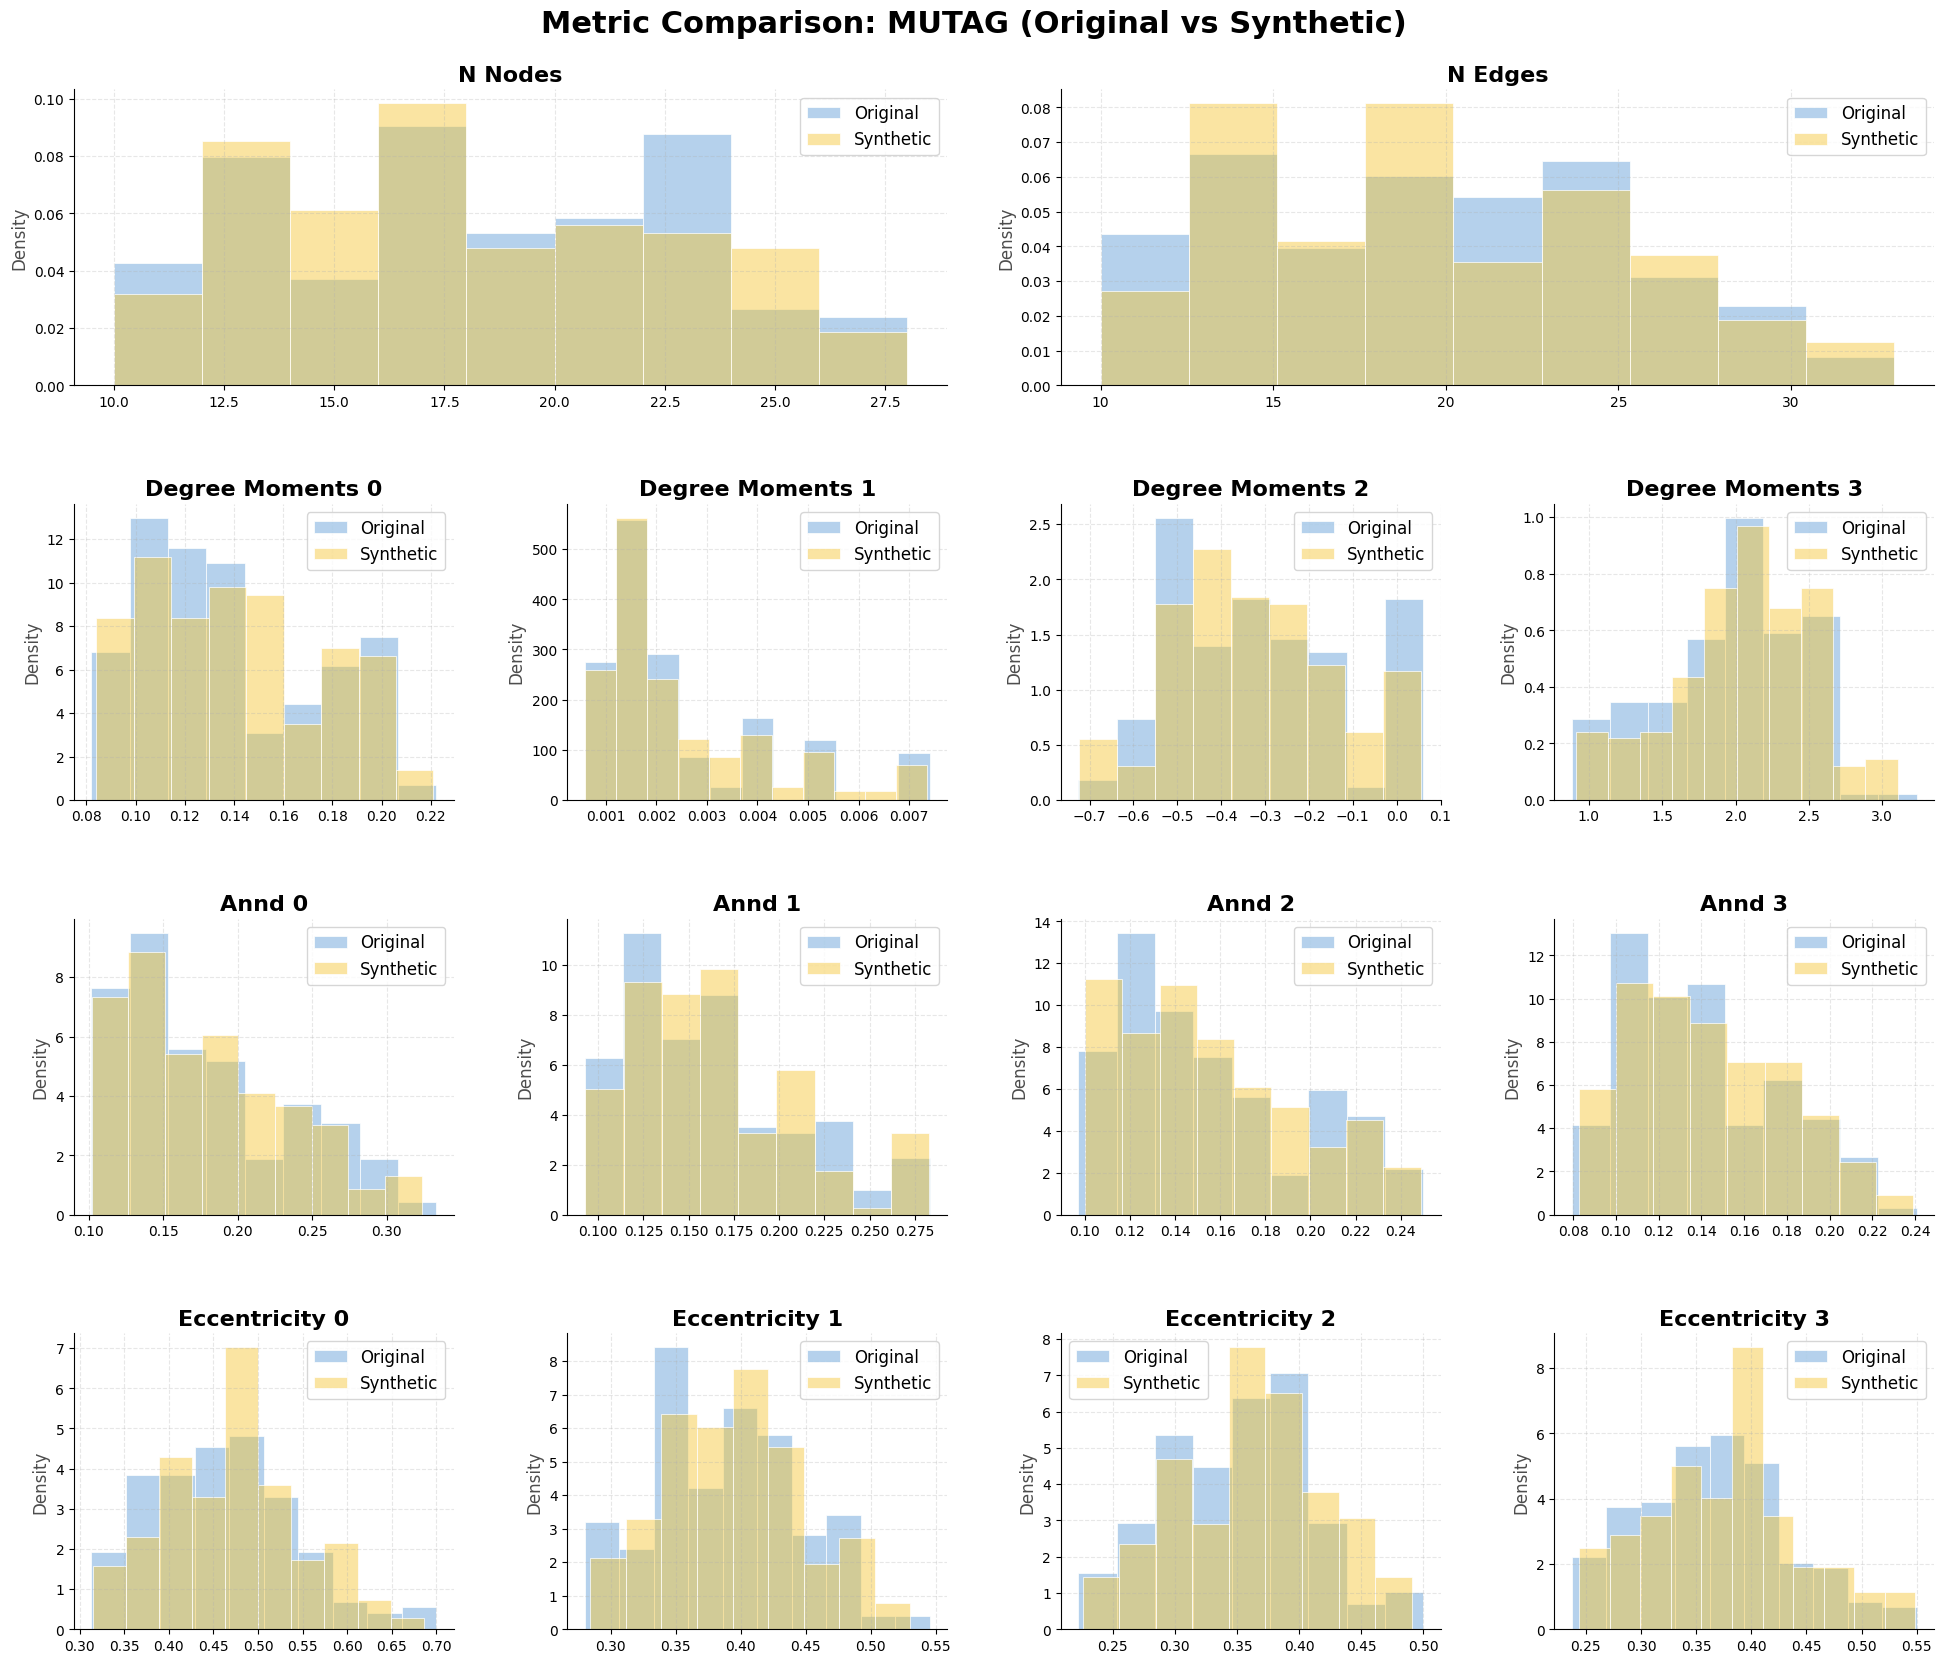


FINAL CONSOLIDATED SUMMARY (Mean Wasserstein Distances across all datasets)


,n_nodes,n_edges,degree_moments_0,degree_moments_1,degree_moments_2,degree_moments_3,annd_0,annd_1,annd_2,annd_3,eccentricity_0,eccentricity_1,eccentricity_2,eccentricity_3,GLOBAL_SCORE
Dataset,,,,,,,,,,,,,,,
BZR,0.018743,0.018807,0.014515,0.010762,0.017490,0.015805,0.014011,0.014361,0.016604,0.012463,0.018218,0.015448,0.014025,0.015093,0.015453
DHFR,0.009985,0.010709,0.016460,0.016152,0.016664,0.013524,0.011903,0.015162,0.014780,0.014600,0.012174,0.011931,0.016482,0.014078,0.013900
Mutagenicity,0.033969,0.013272,0.027753,0.027516,0.016644,0.028319,0.026210,0.022896,0.025514,0.021079,0.020851,0.020470,0.023372,0.022498,0.023597
MUTAG,0.023641,0.017345,0.023711,0.017726,0.025498,0.040668,0.019486,0.024928,0.020871,0.019555,0.030885,0.031085,0.038708,0.038882,0.026642
MEAN,0.021584,0.015033,0.020610,0.018039,0.019074,0.024579,0.017903,0.019337,0.019442,0.016924,0.020532,0.019733,0.023147,0.022638,0.019898



>>> FINAL PERFORMANCE (Average Global Score): 0.0199 <<<


In [4]:
def plot_dataset_comparison(df_orig: pd.DataFrame, df_synth: pd.DataFrame, dataset_name: str) -> None:
    """Plots distributions of all metrics for original vs synthetic datasets."""
    n_rows = 4  # 1 row for discrete + rows for continuous
    
    fig = plt.figure(figsize=(24, 5 * n_rows))
    fig.suptitle(f"Metric Comparison: {dataset_name} (Original vs Synthetic)", fontsize=22, fontweight="bold", y=0.92)
    gs = fig.add_gridspec(n_rows, 4, hspace=0.4, wspace=0.3)
    
    # Define mapping of feature to subplot
    metrics_map = []
    # Row 0: Discrete features (spanning 2 columns each)
    metrics_map.append((DISCRETE_FEATURES[0], fig.add_subplot(gs[0, :2])))
    metrics_map.append((DISCRETE_FEATURES[1], fig.add_subplot(gs[0, 2:])))    
    # Rows 1+: Continuous features (4 per row)
    for i, feat in enumerate(CONTINUOUS_FEATURES):
        row, col = divmod(i, 4)
        metrics_map.append((feat, fig.add_subplot(gs[row + 1, col])))
        
    for feat, ax in metrics_map:
        if feat not in df_orig.columns:
            ax.axis("off")
            continue
            
        # Plot distributions
        for data, label, color in [(df_orig, "Original", "#5B9BD5"), (df_synth, "Synthetic", "#F5C431")]:
            sns.histplot(
                data=data, x=feat, ax=ax, label=label,
                color=color, alpha=0.45, stat="density", element="bars",
                linewidth=0.5, edgecolor="white"
            )
        
        ax.set_title(feat.replace("_", " ").title(), fontsize=16, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("Density", fontsize=12, alpha=0.7)
        ax.legend(fontsize=12, frameon=True, facecolor="white", framealpha=0.8)
        ax.grid(True, linestyle="--", alpha=0.3)
        sns.despine(ax=ax)
        
    plt.show()

def compute_wassestrain_distance(df_orig: pd.DataFrame, df_synth: pd.DataFrame) -> dict:
    """Computes the Wasserstein distance for each feature using anchored Min-Max scaling.
    
    Args:
        df_orig: Original dataset DataFrame
        df_synth: Synthetic dataset DataFrame
    Returns:
        Dictionary mapping feature names to their Wasserstein distance
    """
    results = {}
    for feat in FEATURES:
        if feat not in df_orig.columns or feat not in df_synth.columns:
            raise ValueError(f"Feature {feat} not found in both datasets.")
            
        orig_values = df_orig[feat].values
        synth_values = df_synth[feat].values
        
        # 1. Anchored Min-Max Scaling
        min_val = np.min(orig_values)
        max_val = np.max(orig_values)
        range_val = max_val - min_val
        
        if range_val > 0:
            orig_scaled = (orig_values - min_val) / range_val
            synth_scaled = (synth_values - min_val) / range_val
        else:
            orig_scaled = orig_values - min_val
            synth_scaled = synth_values - min_val
            
        # 2. Wasserstein Distance calculation
        dist = wasserstein_distance(orig_scaled, synth_scaled)
        results[feat] = dist
        
    return results


all_distances_results = []

for dataset_name in DATASETS:
    df_orig = df[df["dataset"] == dataset_name]
    df_synth = df_synthetic[df_synthetic["dataset"] == dataset_name]
    
    # Visualization
    plot_dataset_comparison(df_orig, df_synth, dataset_name)
    
    # Statistical Evaluation
    distances = compute_wassestrain_distance(df_orig, df_synth)
    global_score = np.mean(list(distances.values()))
    
    # Store results
    res_row = {"Dataset": dataset_name}
    res_row.update(distances)
    res_row["GLOBAL_SCORE"] = global_score
    all_distances_results.append(res_row)
    
# Final Summary Aggregation
print("\n" + "="*100)
print("FINAL CONSOLIDATED SUMMARY (Mean Wasserstein Distances across all datasets)")
print("="*100)

df_summary = pd.DataFrame(all_distances_results).set_index("Dataset")
# Add a "MEAN" row to aggregate results across all datasets
df_summary.loc["MEAN"] = df_summary.mean()

display(df_summary)

final_avg_global = df_summary.loc["MEAN", "GLOBAL_SCORE"]
print(f"\n>>> FINAL PERFORMANCE (Average Global Score): {final_avg_global:.4f} <<<")

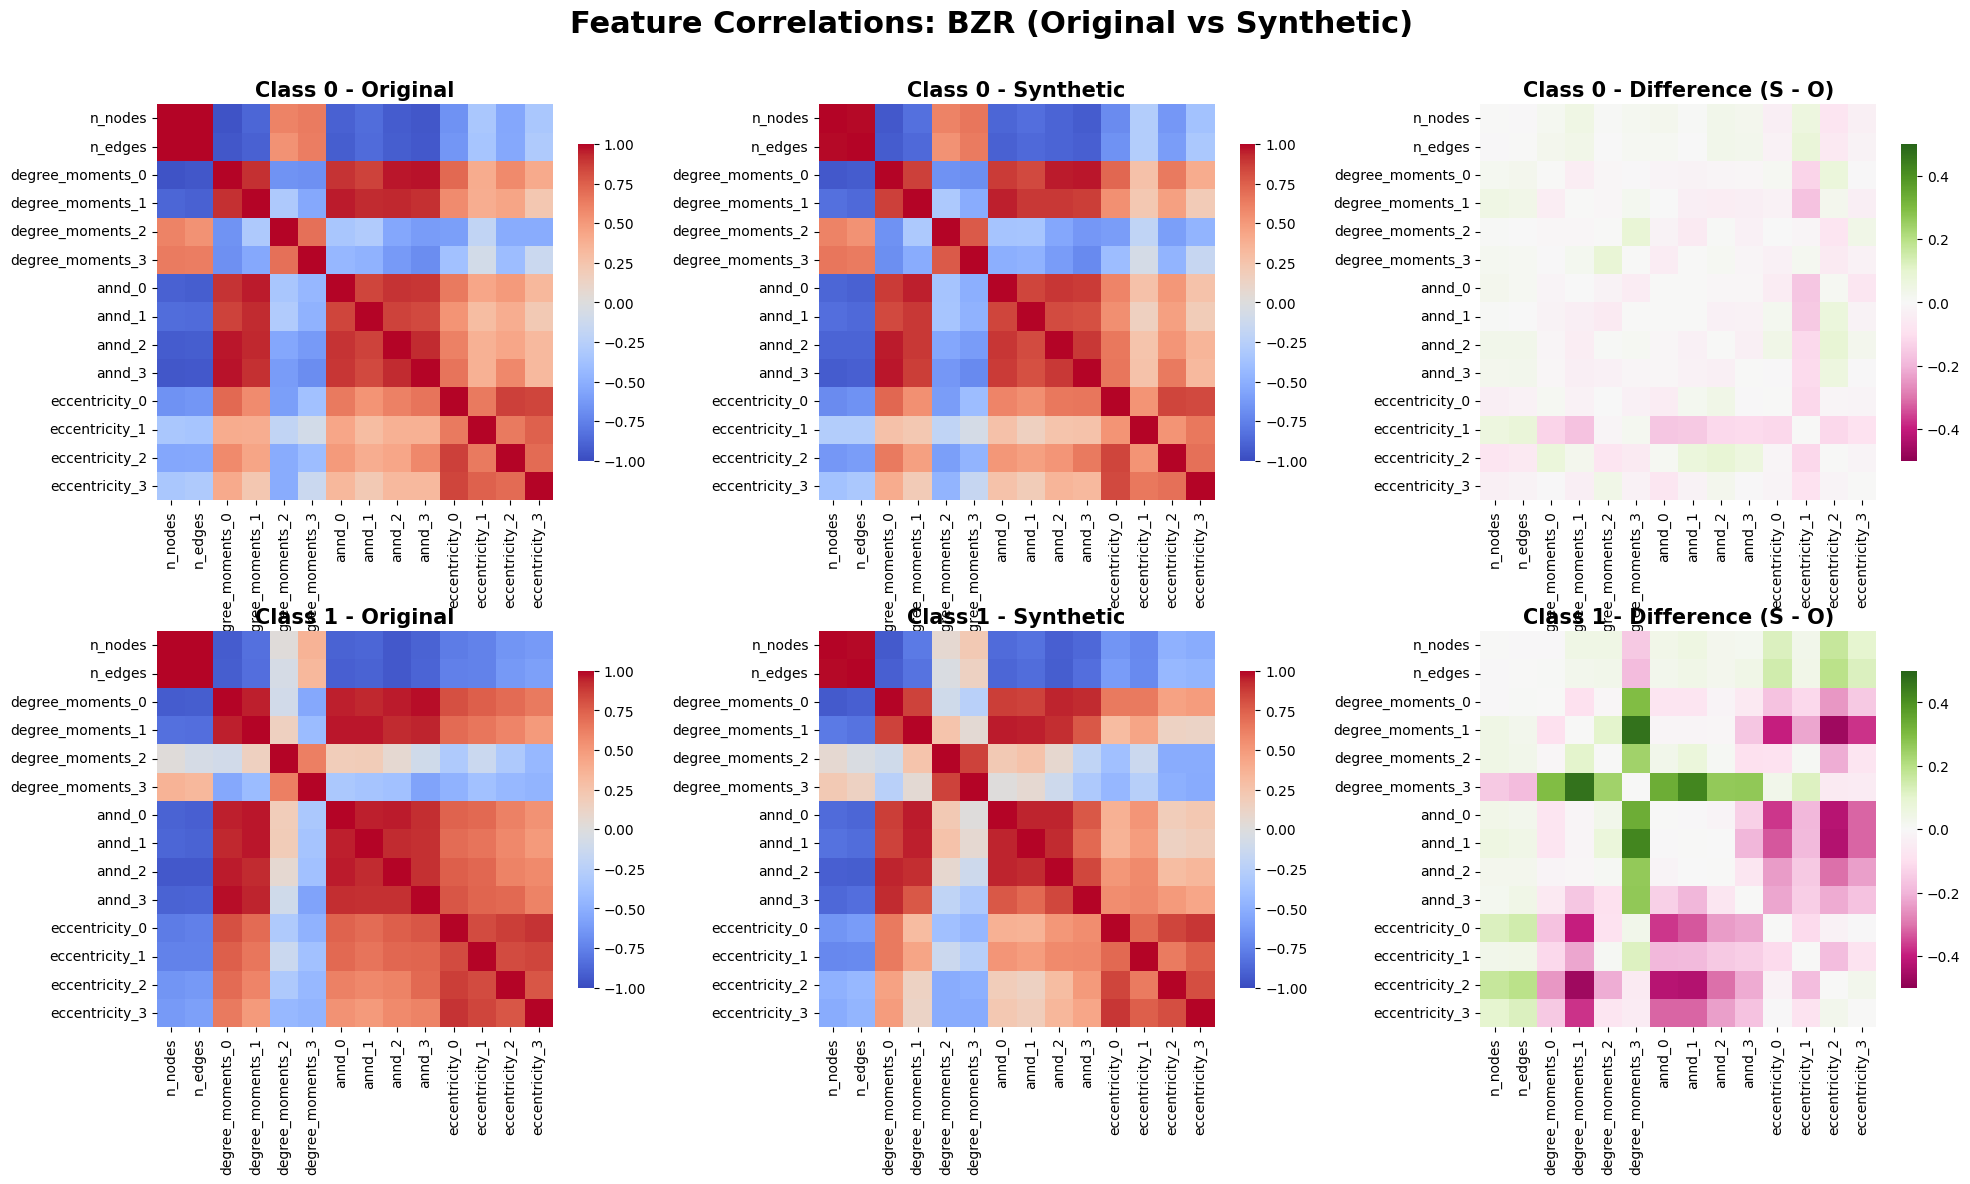

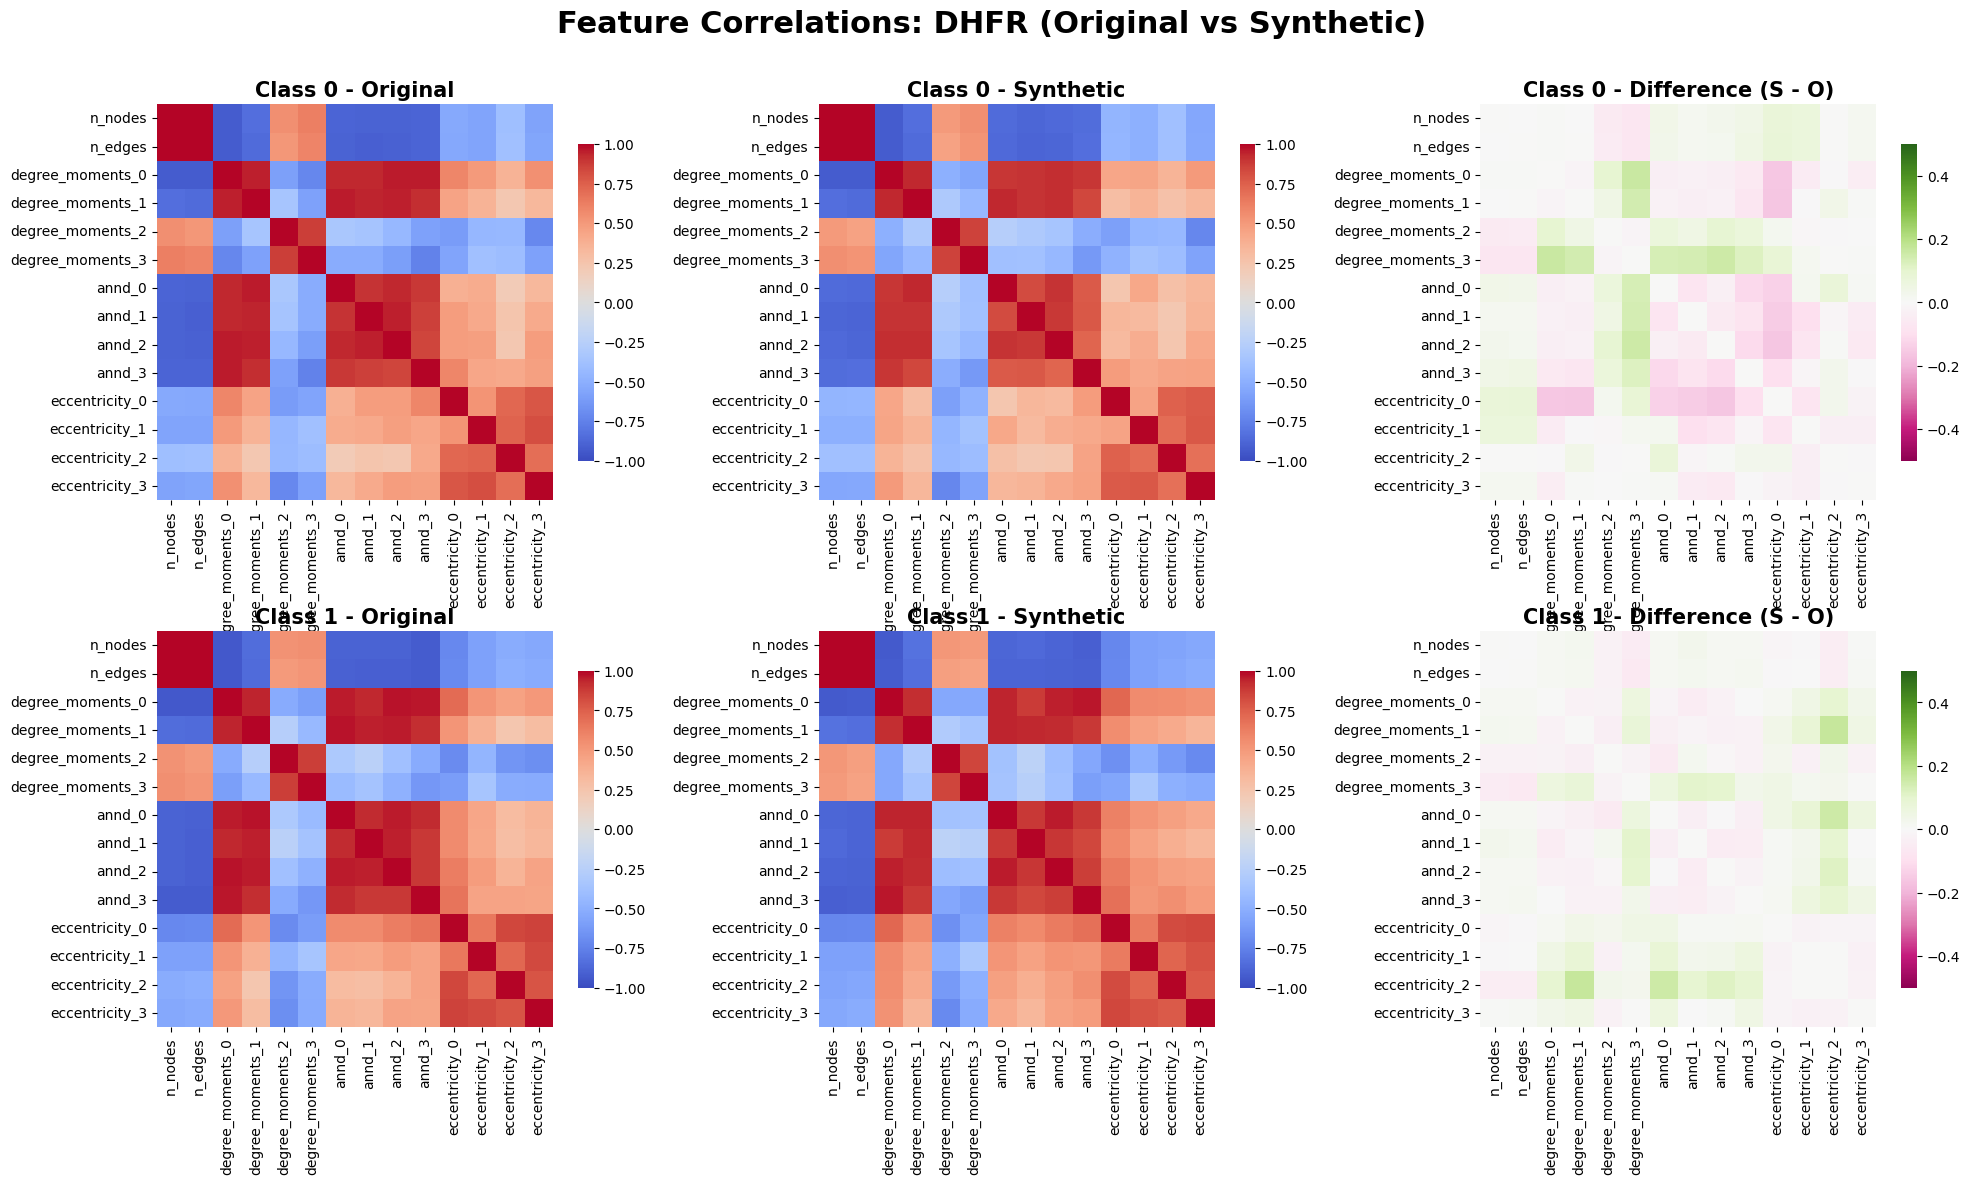

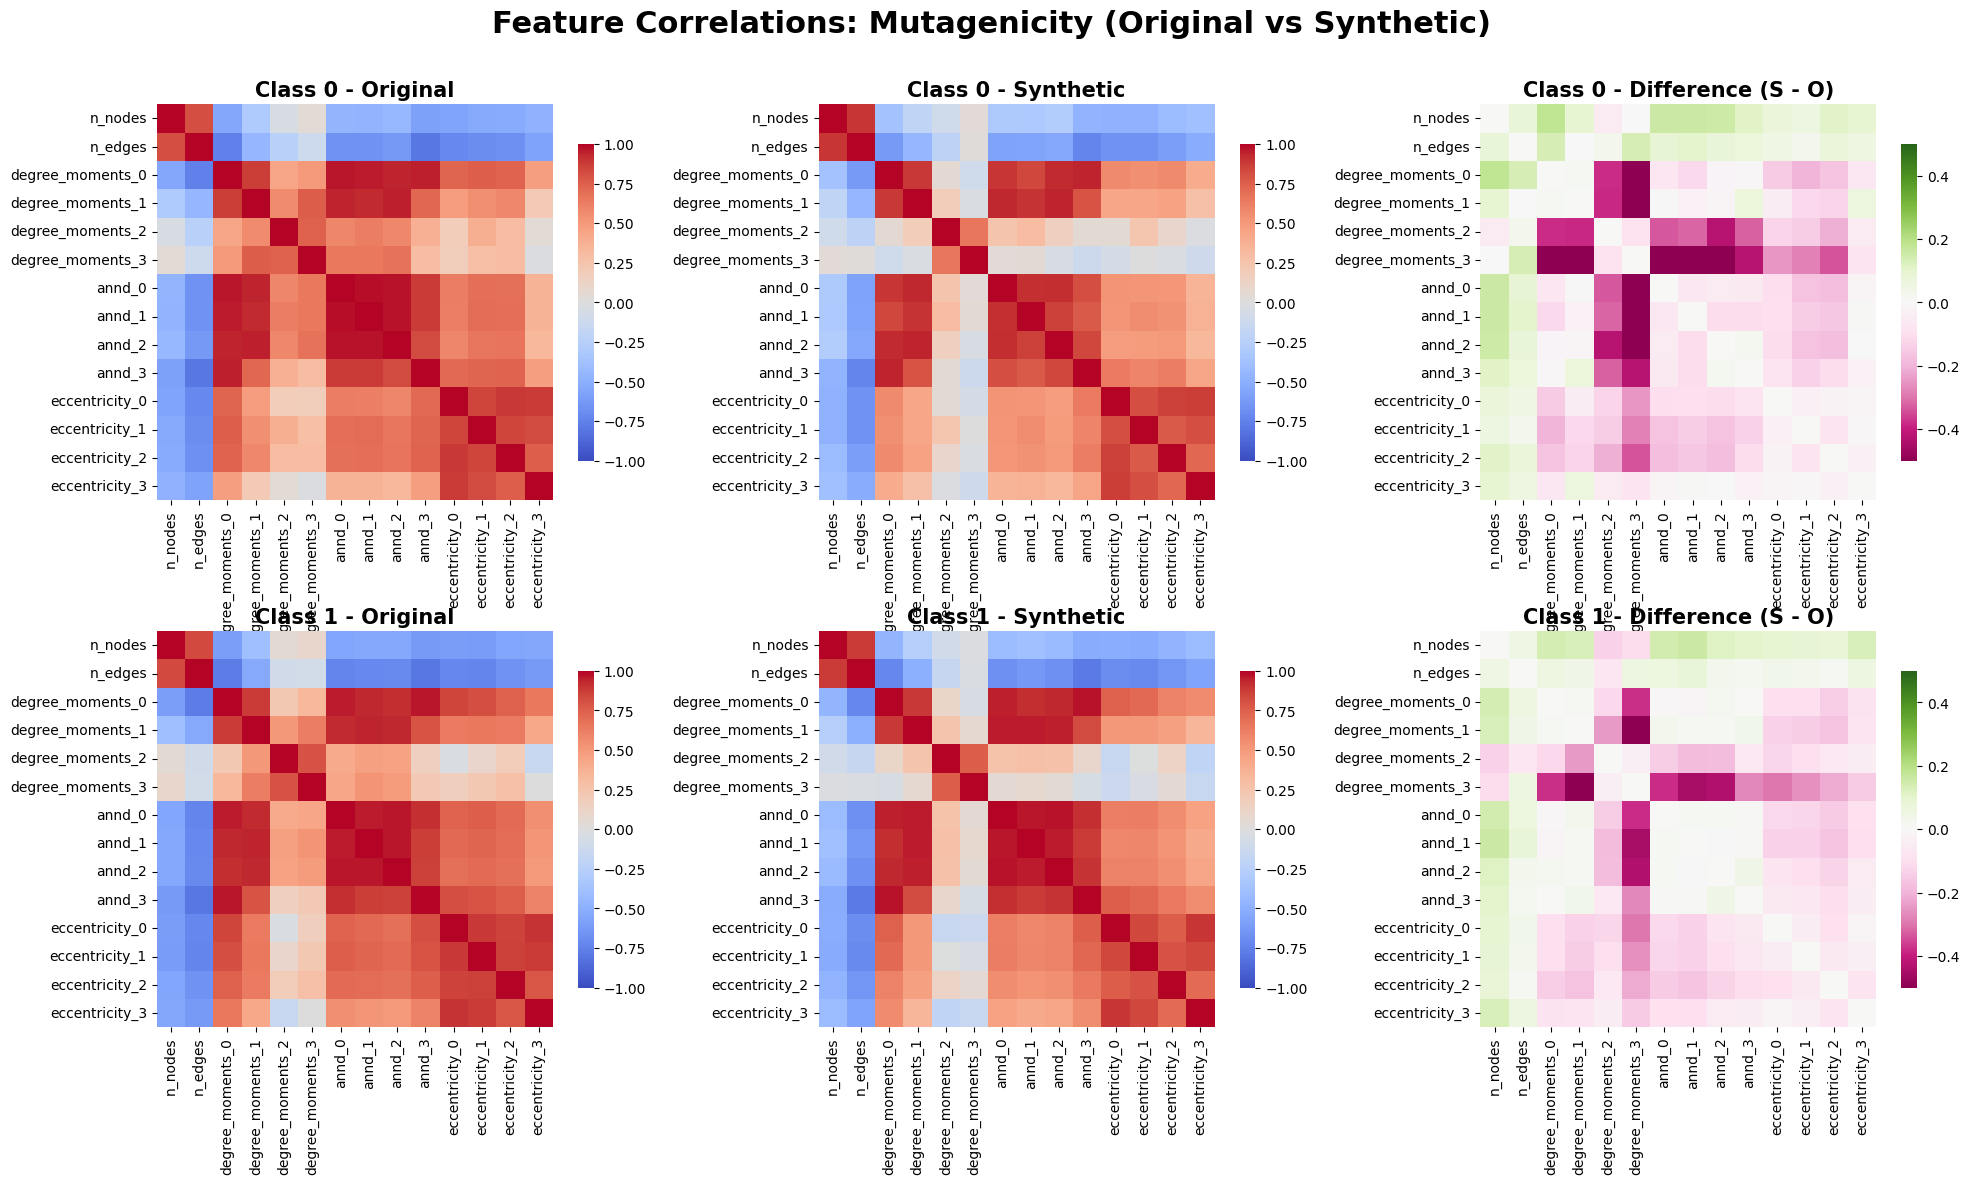

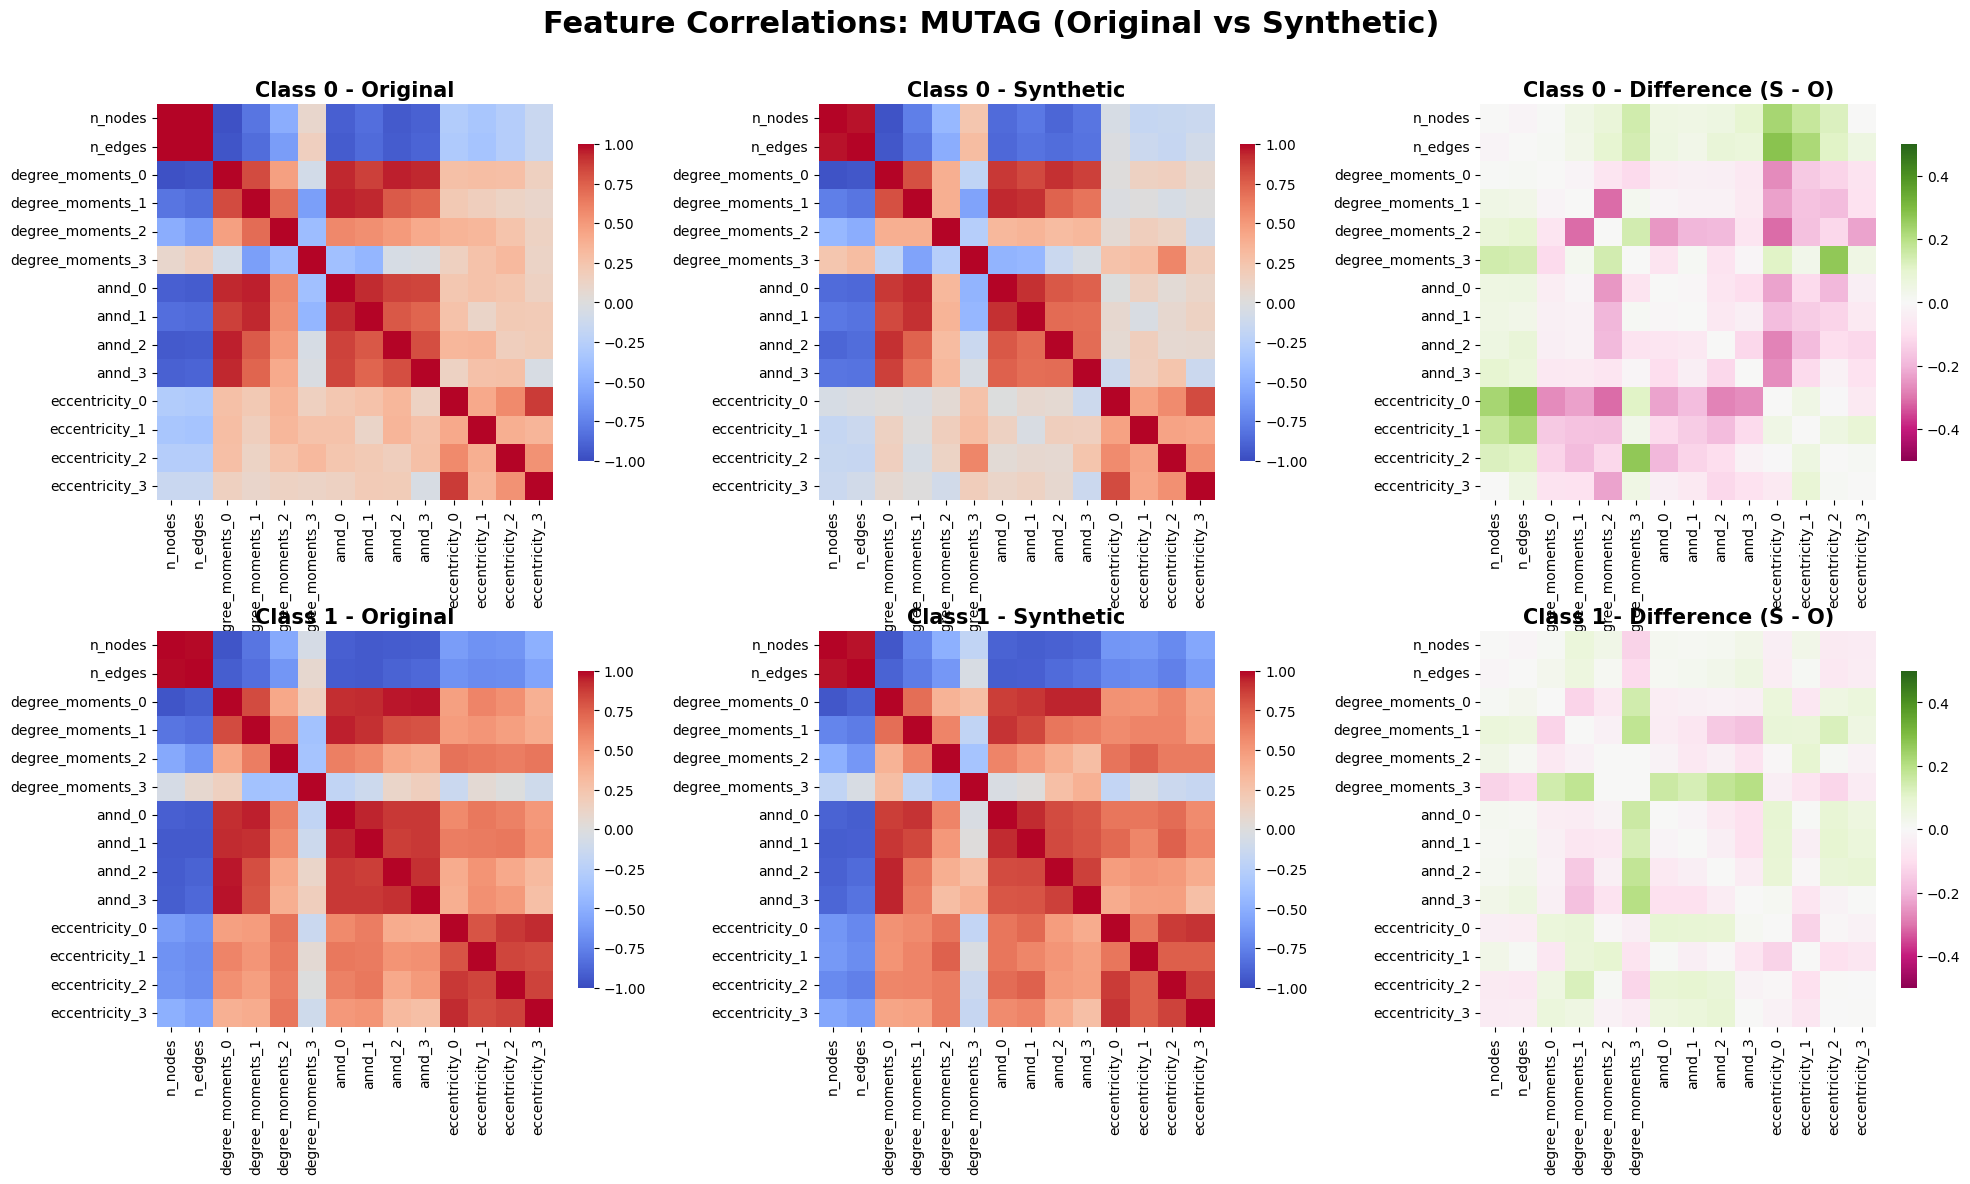


FINAL CORRELATION FIDELITY SUMMARY (Mean Absolute Error)


,Correlation_MAE
Dataset,
BZR,0.083440
DHFR,0.041101
Mutagenicity,0.118195
MUTAG,0.078715
MEAN,0.080363



>>> FINAL CORRELATION PERFORMANCE (Average MAE): 0.0804 <<<


In [5]:
def plot_correlation_matrix(df_orig: pd.DataFrame, df_synth: pd.DataFrame, dataset_name: str) -> list[np.ndarray]:
    """Plots correlation heatmaps between original and synthetic metrics for each class.
    
    Args:
        df_orig: Original dataset DataFrame
        df_synth: Synthetic dataset DataFrame
        dataset_name: Name of the dataset
    Returns:
        List of correlation difference matrices (one per class)
    """
    classes = sorted(df_orig["class_id"].unique())
    n_classes = len(classes)
    
    fig, axes = plt.subplots(n_classes, 3, figsize=(20, 6 * n_classes))
    if n_classes == 1:
        axes = axes.reshape(1, 3)
        
    fig.suptitle(f"Feature Correlations: {dataset_name} (Original vs Synthetic)", fontsize=22, fontweight="bold", y=0.99)
    
    diff_matrices = []
    
    for i, class_id in enumerate(classes):
        # Filter by class
        orig_cls = df_orig[df_orig["class_id"] == class_id][FEATURES]
        synth_cls = df_synth[df_synth["class_id"] == class_id][FEATURES]
        
        # Calculate Pearson correlations
        corr_orig = orig_cls.corr().fillna(0)
        corr_synth = synth_cls.corr().fillna(0)
        corr_diff = corr_synth - corr_orig
        
        diff_matrices.append(corr_diff.values)
        
        # Heatmap styling
        heatmap_kwargs = {
            "center": 0,
            "annot": False,
            "square": True,
            "cbar_kws": {"shrink": 0.8}
        }
        
        # 1. Original Matrix
        sns.heatmap(corr_orig, ax=axes[i, 0], cmap="coolwarm", vmin=-1, vmax=1, **heatmap_kwargs)
        axes[i, 0].set_title(f"Class {class_id} - Original", fontsize=15, fontweight="bold")
        
        # 2. Synthetic Matrix
        sns.heatmap(corr_synth, ax=axes[i, 1], cmap="coolwarm", vmin=-1, vmax=1, **heatmap_kwargs)
        axes[i, 1].set_title(f"Class {class_id} - Synthetic", fontsize=15, fontweight="bold")
        
        # 3. Difference Matrix (Synthetic - Original)
        # Use a different colormap to highlight discrepancies
        sns.heatmap(corr_diff, ax=axes[i, 2], cmap="PiYG", vmin=-0.5, vmax=0.5, **heatmap_kwargs)
        axes[i, 2].set_title(f"Class {class_id} - Difference (S - O)", fontsize=15, fontweight="bold")

    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.show()
    
    return diff_matrices


all_corr_errors = []

for dataset_name in DATASETS:
    df_orig = df[df["dataset"] == dataset_name]
    df_synth = df_synthetic[df_synthetic["dataset"] == dataset_name]
    
    # Correlation Analysis
    diff_mats = plot_correlation_matrix(df_orig, df_synth, dataset_name)
    
    # Compute global correlation error
    avg_corr_err = np.mean([np.abs(m).mean() for m in diff_mats])
    all_corr_errors.append({"Dataset": dataset_name, "Correlation_MAE": avg_corr_err})

# Final Correlation Summary Table
print("\n" + "="*100)
print("FINAL CORRELATION FIDELITY SUMMARY (Mean Absolute Error)")
print("="*100)
df_corr_summary = pd.DataFrame(all_corr_errors).set_index("Dataset")
df_corr_summary.loc["MEAN"] = df_corr_summary.mean()

display(df_corr_summary)

final_avg_corr = df_corr_summary.loc["MEAN", "Correlation_MAE"]
print(f"\n>>> FINAL CORRELATION PERFORMANCE (Average MAE): {final_avg_corr:.4f} <<<")

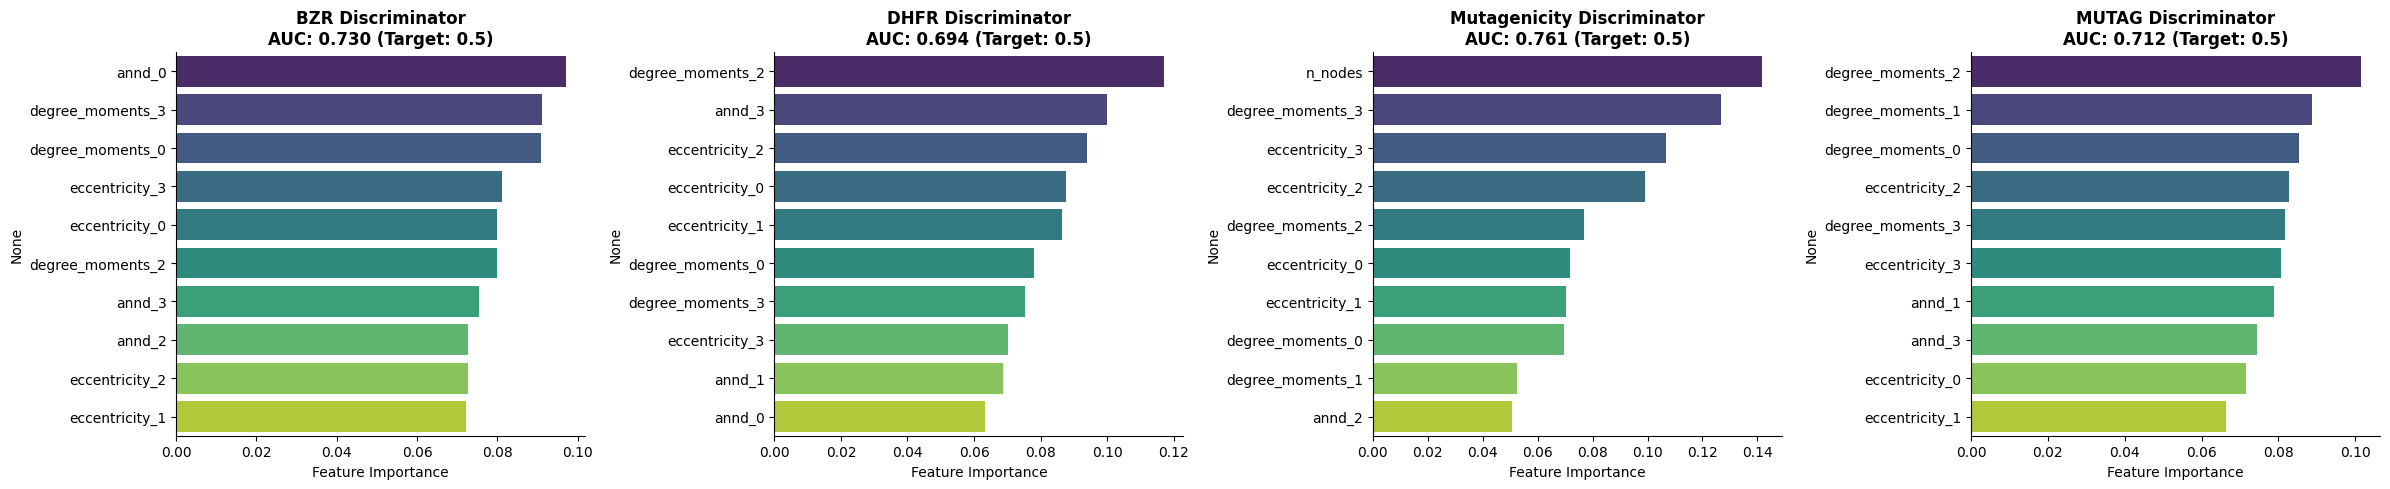

,Discriminator_AUC,Discriminator_Accuracy,Top_Giveaway_Feature
Dataset,,,
BZR,0.730321,0.629630,annd_0
DHFR,0.694483,0.638767,degree_moments_2
Mutagenicity,0.760583,0.655000,n_nodes
MUTAG,0.712406,0.654867,degree_moments_2
MEAN,0.724448,0.644566,NaN



>>> FINAL DISCRIMINATOR AUC: 0.7244 (Closer to 0.5 is better) <<<


In [6]:
def run_adversarial_check(df_orig: pd.DataFrame, df_synth: pd.DataFrame, dataset_name: str, ax=None) -> dict:
    """Trains a discriminator to distinguish between real and synthetic data."""
    
    # Assign label 0 to original, 1 to synthetic
    df_orig_eval = df_orig[FEATURES].copy()
    df_orig_eval["is_synthetic"] = 0
    df_synth_eval = df_synth[FEATURES].copy()
    df_synth_eval["is_synthetic"] = 1
    
    # Combine datasets
    df_eval = pd.concat([df_orig_eval, df_synth_eval], ignore_index=True)
    X = df_eval[FEATURES]
    y = df_eval["is_synthetic"]
    
    # Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    
    # Train Discriminator
    classifier = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)
    classifier.fit(X_train, y_train)
    
    # Predict and Evaluate
    y_pred_proba = classifier.predict_proba(X_test)[:, 1]
    y_pred = classifier.predict(X_test)
    
    auc_score = roc_auc_score(y_test, y_pred_proba)
    acc_score = accuracy_score(y_test, y_pred)
    
    # Extract Feature Importance
    importances = pd.Series(classifier.feature_importances_, index=FEATURES).sort_values(ascending=False)
    
    # Plotting Feature Importance if an axis is provided
    if ax is not None:
        sns.barplot(x=importances.values[:10], y=importances.index[:10], ax=ax, palette="viridis", hue=importances.index[:10])
        ax.set_title(f"{dataset_name} Discriminator\nAUC: {auc_score:.3f} (Target: 0.5)", fontweight="bold")
        ax.set_xlabel("Feature Importance")
        sns.despine(ax=ax)
        
    return {
        "Dataset": dataset_name,
        "Discriminator_AUC": auc_score,
        "Discriminator_Accuracy": acc_score,
        "Top_Giveaway_Feature": importances.index[0]
    }

all_adversarial_results = []
fig, axes = plt.subplots(1, len(DATASETS), figsize=(6 * len(DATASETS), 5))
if len(DATASETS) == 1: axes = [axes]

for i, dataset_name in enumerate(DATASETS):
    df_o = df[df["dataset"] == dataset_name]
    df_s = df_synthetic[df_synthetic["dataset"] == dataset_name]
    
    res = run_adversarial_check(df_o, df_s, dataset_name, ax=axes[i])
    all_adversarial_results.append(res)

plt.tight_layout()
plt.show()

# Final Summary Table
df_adv_summary = pd.DataFrame(all_adversarial_results).set_index("Dataset")
df_adv_summary.loc["MEAN"] = df_adv_summary[["Discriminator_AUC", "Discriminator_Accuracy"]].mean()

display(df_adv_summary)

final_avg_auc = df_adv_summary.loc["MEAN", "Discriminator_AUC"]
print(f"\n>>> FINAL DISCRIMINATOR AUC: {final_avg_auc:.4f} (Closer to 0.5 is better) <<<")

In [11]:
N_REPEATS = 5

def _make_encoder_decoder_configs(num_classes: int) -> list[tuple[str, "FeatureEncoderDecoder"]]:
    """Instantiates all encoder/decoder variants to benchmark."""
    rng = np.random.default_rng(seed=0)
    return [
        ("Moments", MomentsEncoderDecoder(num_classes=num_classes, is_discrete=IS_DISCRETE, k=4, rng=rng)),
        ("Percentile(no_corr)",PercentileEncoderDecoder(num_classes=num_classes, is_discrete=IS_DISCRETE, percentile_size=0.1, replicate_correlation=False, rng=rng)),
        ("Percentile(corr)",PercentileEncoderDecoder(num_classes=num_classes, is_discrete=IS_DISCRETE, percentile_size=0.1, replicate_correlation=True, rng=rng)),
        ("GMCM", GMCMEncoderDecoder(num_classes=num_classes, is_discrete=IS_DISCRETE, percentile_size=0.1, n_components=10, rng=rng)),
    ]


def _compute_mean_wasserstein_per_class(df_orig_cls: pd.DataFrame, df_synth_cls: pd.DataFrame) -> float:
    """Mean Wasserstein distance across all marginal distributions for a single class.

    Applies anchored Min-Max scaling (from the original distribution) so that
    all features contribute on a comparable scale.

    Args:
        df_orig_cls: Original statistics DataFrame (single class).
        df_synth_cls: Synthetic statistics DataFrame (single class).
    Returns:
        Mean Wasserstein distance across all features.
    """
    distances = []
    for feat in FEATURES:
        orig_vals = df_orig_cls[feat].values.astype(float)
        synth_vals = df_synth_cls[feat].values.astype(float)
        min_val, max_val = orig_vals.min(), orig_vals.max()
        range_val = max_val - min_val
        if range_val > 0:
            orig_scaled = (orig_vals - min_val) / range_val
            synth_scaled = (synth_vals - min_val) / range_val
        else:
            orig_scaled = orig_vals - min_val
            synth_scaled = synth_vals - min_val
        distances.append(wasserstein_distance(orig_scaled, synth_scaled))
    return float(np.mean(distances))


def _compute_correlation_mae_per_class(df_orig_cls: pd.DataFrame, df_synth_cls: pd.DataFrame) -> float:
    """Mean absolute error on the Pearson correlation matrix for a single class.

    Computes the global correlation matrix for original and synthetic samples,
    takes the element-wise absolute difference, and returns its mean.

    Args:
        df_orig_cls: Original statistics DataFrame (single class).
        df_synth_cls: Synthetic statistics DataFrame (single class).
    Returns:
        Mean absolute element-wise correlation error.
    """
    corr_orig = df_orig_cls[FEATURES].corr().fillna(0).values
    corr_synth = df_synth_cls[FEATURES].corr().fillna(0).values
    return float(np.abs(corr_synth - corr_orig).mean())


def _compute_discriminator_auc_per_class(df_orig_cls: pd.DataFrame, df_synth_cls: pd.DataFrame) -> float:
    """AUC-ROC of a Random Forest discriminator (original vs synthetic) for a single class.

    Trains the classifier on 70 % of pooled data and evaluates on the remaining
    30 %. Returns NaN when samples are insufficient for a stratified split.

    Args:
        df_orig_cls: Original statistics DataFrame (single class).
        df_synth_cls: Synthetic statistics DataFrame (single class).
    Returns:
        AUC-ROC score (closer to 0.5 means synthetic and original are indistinguishable).
    """
    df_o = df_orig_cls[FEATURES].copy()
    df_o["label"] = 0
    df_s = df_synth_cls[FEATURES].copy()
    df_s["label"] = 1
    df_combined = pd.concat([df_o, df_s], ignore_index=True)
    X = df_combined[FEATURES].values
    y = df_combined["label"].values

    if len(np.unique(y)) < 2 or len(y) < 6:
        return float("nan")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)

    if len(np.unique(y_test)) < 2:
        return float("nan")

    return float(roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1]))


def _run_single_repeat(enc_dec: "FeatureEncoderDecoder", df_dataset: pd.DataFrame, class_id: int) -> dict:
    """One encode-decode cycle for a (enc_dec, class_id) pair; returns raw metrics.

    Args:
        enc_dec: Encoder/decoder instance to evaluate.
        df_dataset: Full dataset DataFrame for one dataset name.
        class_id: The class ID to encode and then sample from.
    Returns:
        Dict with keys 'wasserstein', 'corr_mae', 'auc_roc'.
    """
    df_cls = df_dataset[df_dataset["class_id"] == class_id]
    stat_matrix = df_cls[FEATURES].values

    enc_dec.encode_features(stat_matrix, int(class_id))

    samples_matrix = enc_dec.sample_features(len(df_cls), int(class_id))
    df_synth_cls = pd.DataFrame(samples_matrix, columns=FEATURES)
    df_synth_cls[DISCRETE_FEATURES] = df_synth_cls[DISCRETE_FEATURES].astype(int)

    return {
        "wasserstein": _compute_mean_wasserstein_per_class(df_cls, df_synth_cls),
        "corr_mae": _compute_correlation_mae_per_class(df_cls, df_synth_cls),
        "auc_roc": _compute_discriminator_auc_per_class(df_cls, df_synth_cls),
    }


def run_benchmark(df: pd.DataFrame, datasets: list[str]) -> pd.DataFrame:
    """Full benchmark over all encoder/decoder classes, datasets, and class IDs."""
    num_classes = int(df["class_id"].max() + 1)
    rows = []

    # Prepare all triplets for progress bar
    tasks = []
    for dataset_name in datasets:
        df_dataset = df[df["dataset"] == dataset_name]
        class_ids = sorted(df_dataset["class_id"].unique())
        enc_dec_configs = _make_encoder_decoder_configs(num_classes)
        for enc_dec_label, enc_dec in enc_dec_configs:
            for class_id in class_ids:
                tasks.append((dataset_name, enc_dec_label, enc_dec, class_id))

    for dataset_name, enc_dec_label, enc_dec, class_id in tqdm(tasks, desc="Benchmarking Encoders"):
        df_dataset = df[df["dataset"] == dataset_name].copy()
        repeat_metrics: list[dict] = []
        for rep in range(N_REPEATS):
            try:
                metrics = _run_single_repeat(enc_dec, df_dataset, class_id)
                repeat_metrics.append(metrics)
            except Exception as exc:
                print(
                    f"  [WARN] {dataset_name} | {enc_dec_label} | class={class_id} | rep={rep}: {exc}"
                )

        if not repeat_metrics:
            continue

        mean_wasserstein = float(np.mean([m["wasserstein"] for m in repeat_metrics]))
        mean_corr_mae = float(np.mean([m["corr_mae"] for m in repeat_metrics]))
        valid_aucs = [m["auc_roc"] for m in repeat_metrics if not np.isnan(m["auc_roc"])]
        mean_auc_roc = float(np.mean(valid_aucs)) if valid_aucs else float("nan")

        rows.append(
            {
                "dataset_name": dataset_name,
                "enc_dec": enc_dec_label,
                "class_id": int(class_id),
                "mean_wasserstein": mean_wasserstein,
                "mean_corr_mae": mean_corr_mae,
                "mean_auc_roc": mean_auc_roc,
            }
        )

    return pd.DataFrame(rows)


df_benchmark = run_benchmark(df, DATASETS)

print("\n" + "=" * 100)
print("FULL BENCHMARK RESULTS  (dataset_name, enc_dec, class_id)")
print("=" * 100)
display(df_benchmark)

print("\n" + "=" * 100)
print("AGGREGATED SUMMARY (mean across all datasets and classes)")
print("=" * 100)
num_classes = int(df["class_id"].max() + 1)
model_order = [cfg[0] for cfg in _make_encoder_decoder_configs(num_classes)]

df_bench_agg = (
    df_benchmark
    .groupby("enc_dec")[["mean_wasserstein", "mean_corr_mae", "mean_auc_roc"]]
    .mean()
    .reindex(model_order)
)
display(df_bench_agg)

Benchmarking Encoders:   0%|          | 0/32 [00:00<?, ?it/s]


FULL BENCHMARK RESULTS  (dataset_name, enc_dec, class_id)


,dataset_name,enc_dec,class_id,mean_wasserstein,mean_corr_mae,mean_auc_roc
0,BZR,Moments,0,0.022582,0.578324,0.997786
1,BZR,Moments,1,0.024169,0.611384,0.999112
2,BZR,Percentile(no_corr),0,0.022343,0.577854,0.995768
3,BZR,Percentile(no_corr),1,0.030935,0.609051,0.994675
4,BZR,Percentile(corr),0,0.019819,0.043915,0.819032
5,BZR,Percentile(corr),1,0.031446,0.090631,0.562426
6,BZR,GMCM,0,0.017633,0.033654,0.713824
7,BZR,GMCM,1,0.028020,0.058654,0.567899
8,DHFR,Moments,0,0.026260,0.585975,0.995327
9,DHFR,Moments,1,0.022124,0.601653,0.996799



AGGREGATED SUMMARY (mean across all datasets and classes)


,mean_wasserstein,mean_corr_mae,mean_auc_roc
enc_dec,,,
Moments,0.022385,0.567602,0.993931
Percentile(no_corr),0.027009,0.564595,0.986828
Percentile(corr),0.026704,0.074085,0.734352
GMCM,0.021460,0.050551,0.655928
